In the tutorial notebook, we followed the data analysis for a full sector of TESS data. Below is the same procedure for a set of subsectors.

In [1]:
import glob
from figures import *

root = '/home/ktp9/TESSNeptune24/tess-ice-giants/'
data_dir = root + 'final_data/'

bps, pps = 50, 10
bpps_dir = f'bps{bps}_pps{pps}/'

subdir = data_dir + f'subsectors/{bpps_dir}'

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]
sample_cadences = np.array([10/60, 10/60, 10/60, 10/60, (200/60)/60]) # in hours

supfigdir = root + "figures/supplementary/" + bpps_dir



Separate each light curve into ten ~equal subsectors (~5-10 mins)

In [1]:
# load in the light curves
lc_dir = data_dir + "light_curves/" + bpps_dir
lc_list = []
for sector in planet_sectors:
    lc_list.append(np.load(lc_dir + f'{sector}_lcs.npz'))

NameError: name 'data_dir' is not defined

In [13]:
# ~10 min runtime

from subsectors import * 
from fullsector import nyquist_from_cadence

max_freq_arr = nyquist_from_cadence(sample_cadences / 24)

total_segs = 10

times = [sector['time'] for sector in lc_list]
fluxes = [sector['orbit_corrected'] for sector in lc_list]
result = split_data(times, fluxes, 
                    max_freq_arr, freq_array_size=1000,
                    m=50, total_segs=total_segs, 
                    bootstrap=True,
                    verbose=True)

(subtimes, subfluxes, subfreqs, subpower, subfap, subpeaks, subpeakfap) = result

Processing dataset 0
Processing dataset 1
Processing dataset 2
Processing dataset 3
Processing dataset 4


In [ ]:

os.makedirs(subdir, exist_ok=True)
print(f"saving to: {subdir}")
np.savez(subdir + 'subsectors.npz', 
         subtimes=np.array(subtimes, dtype=object), 
         subfluxes=np.array(subfluxes, dtype=object),
         subfreqs=np.array(subfreqs, dtype=object), 
         subpower=np.array(subpower, dtype=object), 
         subfap=np.array(subfap, dtype=object),
         subpeaks=np.array(subpeaks, dtype=object), 
         subpeakfap=np.array(subpeakfap, dtype=object),
         allow_pickle=True)

saving to: /home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps50_pps10/


In [2]:
subsectors = np.load(subdir + 'subsectors.npz', allow_pickle=True)
subtimes = subsectors['subtimes']
subfluxes = subsectors['subfluxes']
subfreqs = np.array(subsectors['subfreqs'], dtype=float)
subpower = subsectors['subpower']
subfap = subsectors['subfap']
subpeakfap = subsectors['subpeakfap']

In [18]:
from bootstrap import bootstrap_peak_periods

nsec, nsub = subtimes.shape

bootstrap_results = np.empty((nsec, nsub), dtype=object)
for sec in range(nsec):
    print(f"Bootstrapping sector {sec+1}/{nsec}...")
    min_period=1/max_freq_arr[sec]

    for sub in range(nsub):
        print(f"Bootstrapping subsector {sub+1}/{nsub}...")
        max_period = (subtimes[sec, sub][-1] - subtimes[sec, sub][0])/2
        print(f"min, max period: {min_period, max_period}")

        peak_periods = bootstrap_peak_periods(subtimes[sec, sub], 
                                              subfluxes[sec, sub], 
                                              fap_level=0.01, 
                                              n_bootstraps=10000, 
                                              boot_percent=0.8, 
                                              min_period=min_period, 
                                              max_period=max_period, 
                                              n_freqs=1000, 
                                              figdir=supfigdir, 
                                              sds=planet_sectors[sec] + f"_ss{sub}",
                                              n_plot=100)
        bootstrap_results[sec, sub] = peak_periods

Bootstrapping sector 1/5...
Bootstrapping subsector 1/10...
min, max period: (0.013888888888888888, 0.9723171042278409)


100%|██████████| 10000/10000 [00:50<00:00, 199.07it/s]


Bootstrapping subsector 2/10...
min, max period: (0.013888888888888888, 0.9723131230566651)


100%|██████████| 10000/10000 [00:49<00:00, 202.13it/s]


Bootstrapping subsector 3/10...
min, max period: (0.013888888888888888, 0.9688381112646312)


...

100%|██████████| 10000/10000 [01:06<00:00, 150.53it/s]


Bootstrapping subsector 9/10...
min, max period: (0.00462962962962963, 1.025417995173484)


100%|██████████| 10000/10000 [01:20<00:00, 124.42it/s]


Bootstrapping subsector 10/10...
min, max period: (0.00462962962962963, 1.0254169015679508)


100%|██████████| 10000/10000 [01:03<00:00, 156.77it/s]


In [20]:
np.savez(subdir + 'bootstrap_results.npz', bootstrap_results=bootstrap_results, allow_pickle=True)

In [3]:
bootstrap_results = np.load(subdir + 'bootstrap_results.npz', allow_pickle=True)['bootstrap_results']
print(bootstrap_results.shape)

(5, 10)


Processing sector 0/5...
Processing sector 1/5...
Processing sector 2/5...
Processing sector 3/5...
Processing sector 4/5...


<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

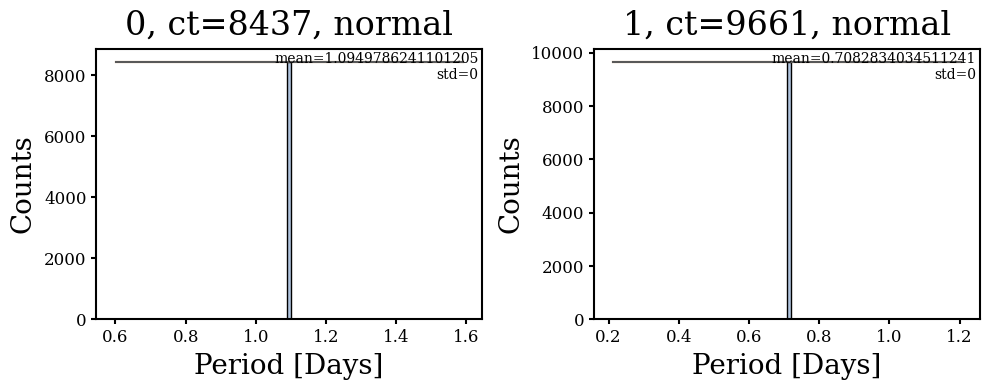

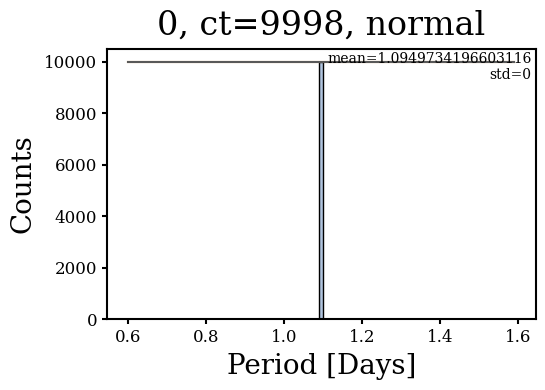

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

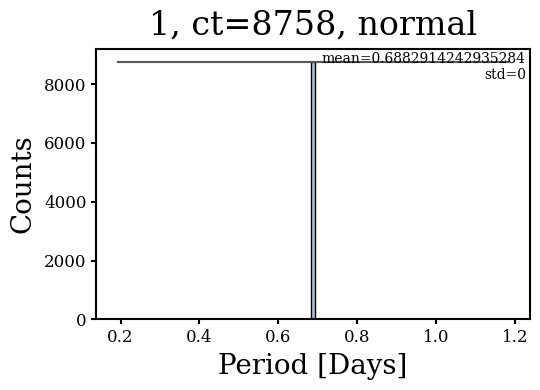

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

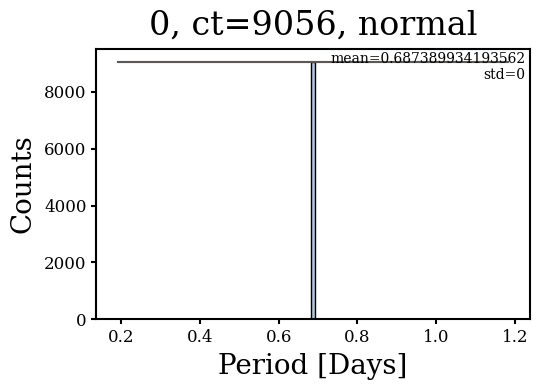

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

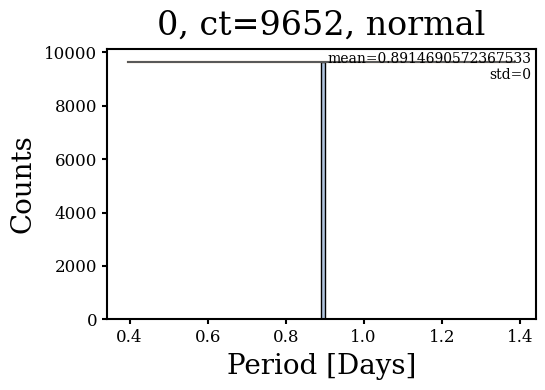

<Figure size 500x400 with 0 Axes>

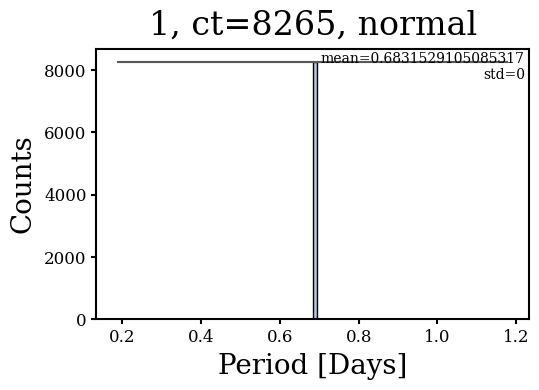

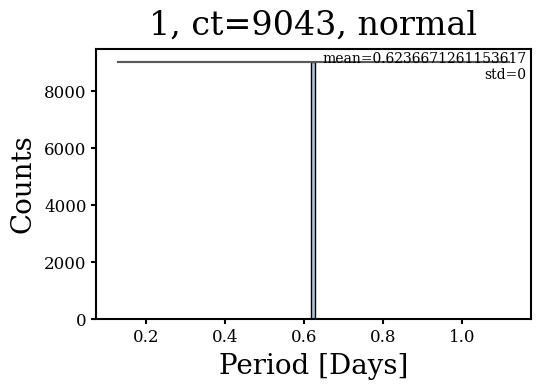

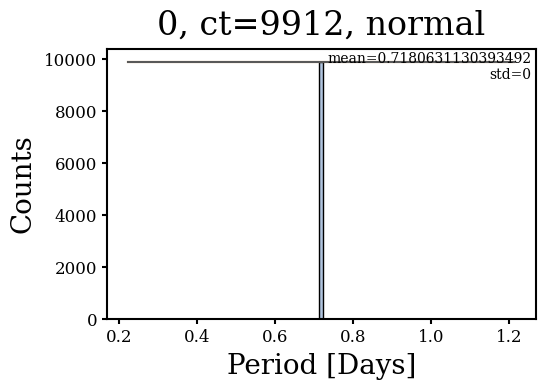

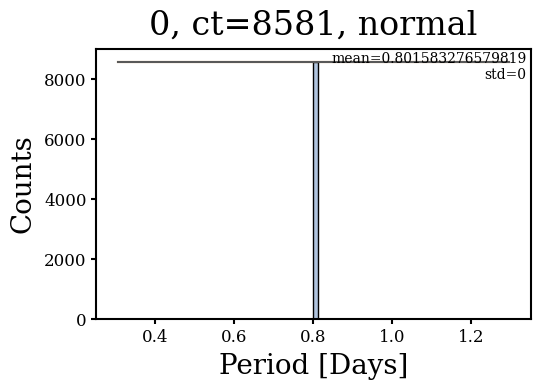

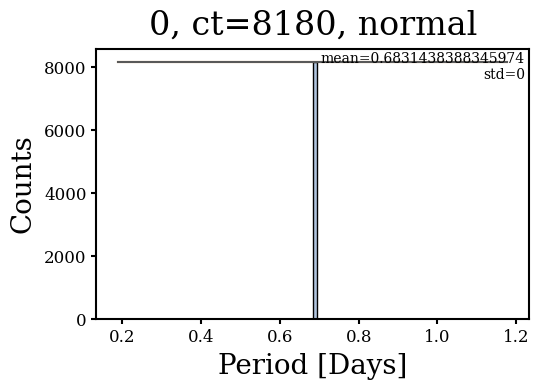

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

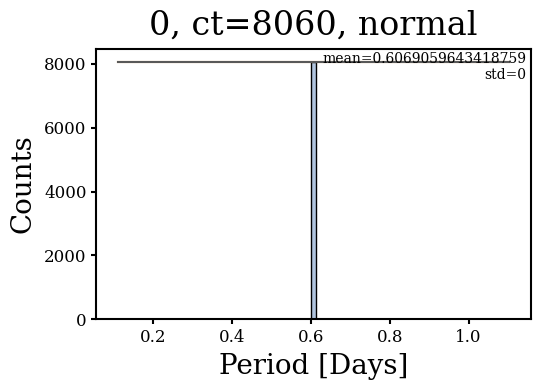

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

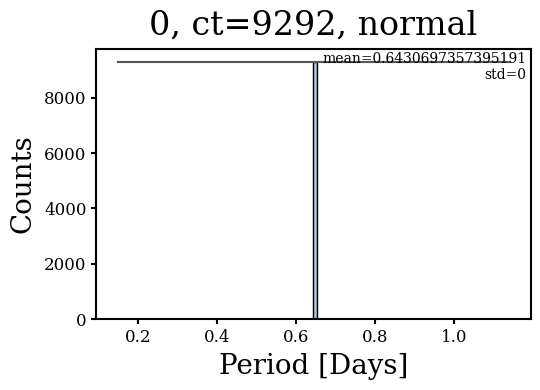

<Figure size 500x400 with 0 Axes>

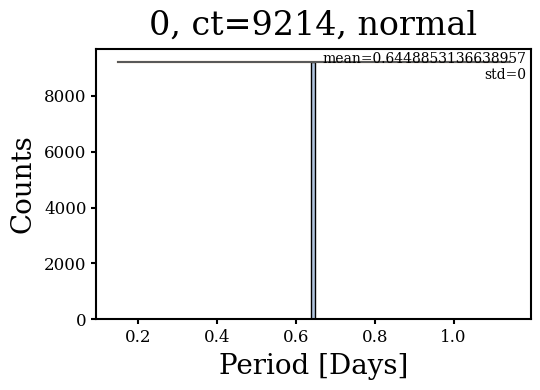

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

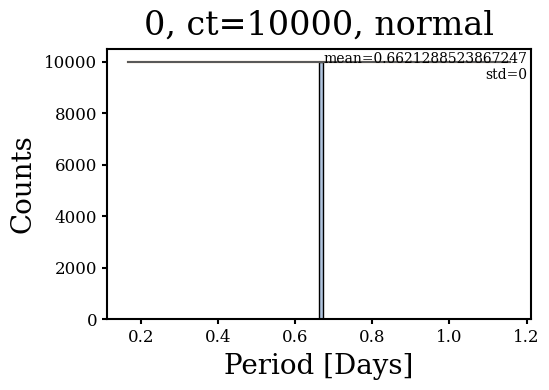

<Figure size 500x400 with 0 Axes>

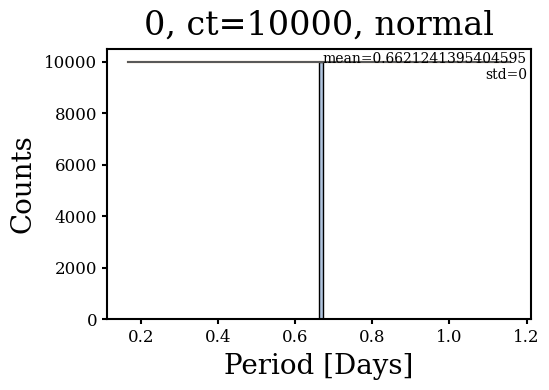

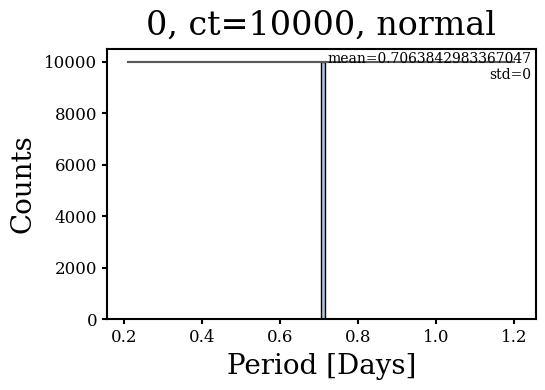

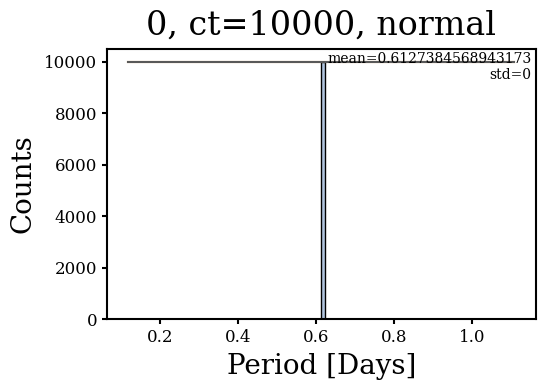

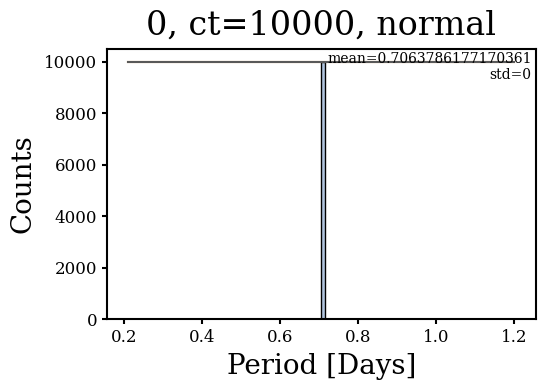

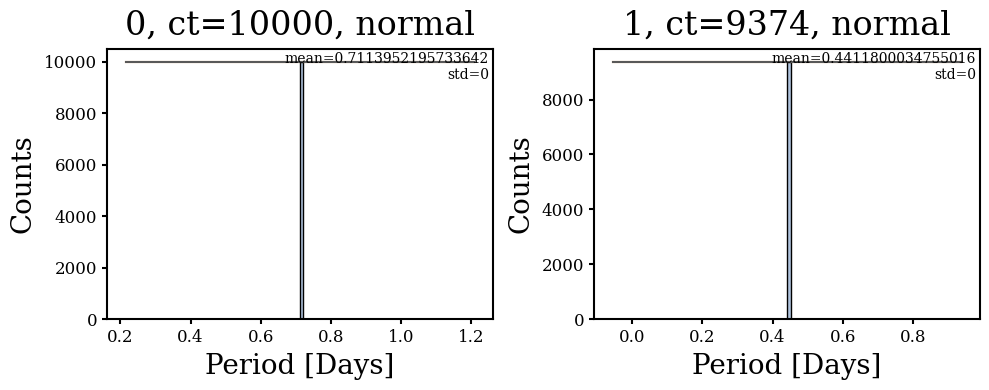

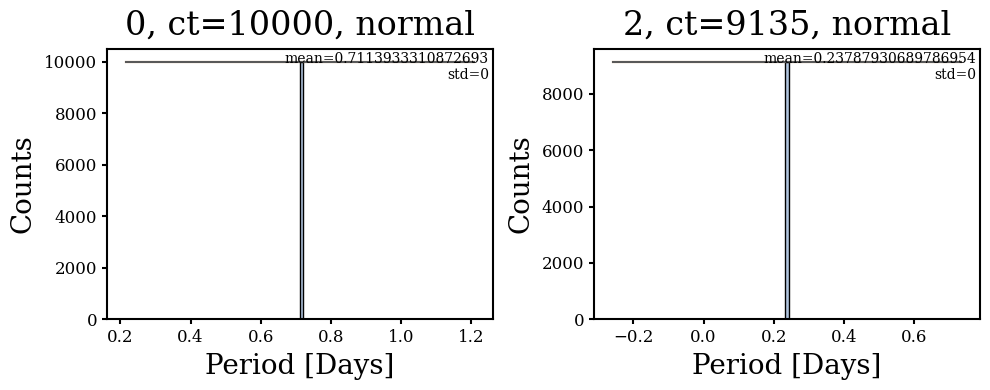

<Figure size 500x400 with 0 Axes>

In [4]:
from bootstrap import cluster_peaks
nsec, nsub = bootstrap_results.shape
cluster_results = np.empty((nsec, nsub), dtype=object)
for sec in range(nsec):
    print(f"Processing sector {sec}/{nsec}...")
    for sub in range(nsub):
        peaks = bootstrap_results[sec, sub]
        labels, all_means, all_stds = cluster_peaks(peaks, 
                                                    sds=planet_sectors[sec] + f"_ss{sub}",
                                                    eps=0.005, 
                                                    n_bootstraps=10000,
                                                    pass_frac=0.8, 
                                                    figdir=supfigdir + "clusters/")
        
        cluster_results[sec, sub] = (labels, all_means, all_stds)

np.savez(subdir + 'cluster_results.npz', cluster_results=cluster_results, allow_pickle=True)

In [5]:
from wind_equations import *
cluster_results = np.load(subdir + 'cluster_results.npz', allow_pickle=True)['cluster_results']
nsec, nsub = cluster_results.shape

ur_wind_eqns = [sromovsky2012_odd_N, sromovsky2012_odd_S, sromovsky2015_N, sromovsky2015_S]
# ur_wind_eqn_errs = [sigma_sromovsky2012_odd_N, sigma_sromovsky2012_odd_S, sigma_sromovsky2015_N, sigma_sromovsky2015_S]
ur_wind_eqn_errs = [sigma_uranus_model(wind_eqn) for wind_eqn in ur_wind_eqns]
ur_wind_eqn_strings = ["sromovsky2012_odd_N", "sromovsky2012_odd_S", "sromovsky2015_N", "sromovsky2015_S"]

nep_wind_eqns = [sromovsky1993_four, sromovsky1993_six, tollefson2013_kp, tollefson2014_kp]
nep_wind_eqn_errs = [sromovsky1993_four_err, sromovsky1993_six_err, tollefson2013_kp_err, tollefson2014_kp_err]
nep_wind_eqn_strings = ["sromovsky1993_four", "sromovsky1993_six", "tollefson2013_kp", "tollefson2014_kp"]

# planet data
uRe = 25559 * 1000
uRp = 24973 * 1000
uP = 17.247864
uRe_err = 4000
uRp_err = 20000
uP_err = 0.00001

nRe = 24764 * 1000
nRp = 24341 * 1000
nP = 15.9663
nRe_err = 15000
nRp_err = 30000
nP_err = 0.0002

reperr12 = 0.088 # degrees/h, pg. 11 of Sromovsky+ 2012c
reperr15 = 0.147 / 24 # 0.147 degrees/day, pg. 11 of Sromovsky+ 2015
reperrs = [reperr12, reperr12, reperr15, reperr15]

In [ ]:
from mcmc import *

mcmc_results = np.empty((nsec, nsub))
for i, sec in enumerate(range(nsec)):
    mcmc_root = subdir + f"{planet_sectors[i]}/"

    for sub in range(nsub):
        labels, all_means, all_stds = cluster_results[sec, sub]
        sector_data = {}
        sector_data['matched_means'] = all_means
        sector_data['matched_stds'] = all_stds
        
        # if len(all_means) > 0:
        #     sector_data['matched_means'].extend(all_means)
        #     sector_data['matched_stds'].extend(all_stds)
        
        # for key in sector_data:
        #     sector_data[key] = np.array(sector_data[key])

        # print(f"Type of sector_data['matched_means']: {type(sector_data['matched_means'])}")
        # print(f"Dtype: {sector_data['matched_means'].dtype if hasattr(sector_data['matched_means'], 'dtype') else 'No dtype'}")
        if planet_sectors[i][0] == "u":
            print("Uranus sector: ", planet_sectors[i], "sub", sub)
            save_mcmc(ur_wind_eqns, ur_wind_eqn_errs, sector_data,
                        uRe, uRp, uP, uRe_err, uRp_err, uP_err, 
                        ur_wind_eqn_strings, f"subsector{sub}", mcmc_root + "mcmc/", reperrs=reperrs)
        elif planet_sectors[i][0] == "n":
            print("Neptune sector: ", planet_sectors[i], "sub", sub)
            save_mcmc(nep_wind_eqns, nep_wind_eqn_errs, sector_data, 
                        nRe, nRp, nP, nRe_err, nRp_err, nP_err, 
                        nep_wind_eqn_strings, f"subsector{sub}", mcmc_root + "mcmc/")


Uranus sector:  u42 sub 0
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_N
[]
Processing wind equation: sromovsky2012_odd_N
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_S
[]
Processing wind equation: sromovsky2012_odd_S
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_N
[]
Processing wind equation: sromovsky2015_N
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_S
[]
Processing wind equation: sromovsky2015_S
saving to:  /home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps50_pps10/u42/mcmc/subsector0_phi_distributions.npz
Uranus sector:  u42 sub 1
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531

100%|██████████| 5000/5000 [01:27<00:00, 56.95it/s]


Median latitude (deg): 28.13440979250022
Std 0.11318605287432844
appended phi_deg of median 28.13440979250022
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_S
[0, 0]
Processing wind equation: sromovsky2012_odd_S
Frequency, error: 1.411864227126432 0.0


100%|██████████| 5000/5000 [01:25<00:00, 58.63it/s]


Median latitude (deg): 24.47968933560103
Std 0.12628371591520923
appended phi_deg of median 24.47968933560103
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_N
[0, 0]
Processing wind equation: sromovsky2015_N
Frequency, error: 1.411864227126432 0.0


...

Median latitude (deg): 89.38432222373427
Std 0.466256695561274
appended phi_deg of median 89.38432222373427
Using minimum frequency of 1.282165943619658 for wind equation tollefson2014_kp
[0, 0]
Processing wind equation: tollefson2014_kp
Frequency, error: 1.4056921203796415 0.0


100%|██████████| 5000/5000 [00:41<00:00, 121.01it/s]


Median latitude (deg): 41.29448261287662
Std 18.919400914433048
appended phi_deg of median 41.29448261287662
Frequency, error: 4.203812483905283 0.0


100%|██████████| 5000/5000 [00:41<00:00, 120.56it/s]


Median latitude (deg): 89.84950706900601
Std 0.20210066506226598
appended phi_deg of median 89.84950706900601
saving to:  /home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps50_pps10/n70/mcmc/subsector8_phi_distributions.npz
Neptune sector:  n70 sub 9
Minimum f with at least one intersection: 1.282166
Minimum f with at least one intersection: 0.010004
Minimum f with at least one intersection: 1.272727
Minimum f with at least one intersection: 0.010004
Using minimum frequency of 1.282165943619658 for wind equation sromovsky1993_four
[]
Processing wind equation: sromovsky1993_four
Using minimum frequency of 1.282165943619658 for wind equation sromovsky1993_six
[]
Processing wind equation: sromovsky1993_six
Using minimum frequency of 1.272727441932361 for wind equation tollefson2013_kp
[]
Processing wind equation: tollefson2013_kp
Using minimum frequency of 1.282165943619658 for wind equation tollefson2014_kp
[]
Processing wind equation: tollefson2014_kp
saving to:  /home/kt

In [2]:
import glob
import os
from tqdm import tqdm 
import re

from mcmc import fit_all_distributions

import glob

from mcmc import fit_all_distributions

subroot = root + "subsectors"

print(root)
for sector in planet_sectors:
    secsubroot = subdir + "/" + sector
    mcmc_list = glob.glob(secsubroot + "/mcmc/*")
    mcmc_list.sort(key=lambda x: int(re.search(r'subsector(\d+)', x).group(1)))

    for i, phi_file in enumerate(mcmc_list):
        print(phi_file)
        print(sector, i)

        phi_dist = np.load(phi_file, allow_pickle=True)
        phi_data = phi_dist['phi_distributions']

        print(phi_data)
        # for data in phi_data:
        #     if len(data) > 0:
        #         print("mean, std", np.median(data), np.std(data))
        #     else:
        #         continue
        all_latitudes, all_standard_devs = fit_all_distributions(phi_dist["phi_distributions"], 
                                                                        phi_dist["wind_eqn_strings"], 
                                                                        verbose=False,
                                                                        truncbound=None, 
                                                                        sds=sector, 
                                                                        figdir=supfigdir + "subposteriors/")

        print(all_latitudes, all_standard_devs)

        if os.path.exists(secsubroot + "/latitudes/") == False:
            os.makedirs(secsubroot + "/latitudes/")
        np.savez(secsubroot + "/latitudes/" + f"{sector}_sub{i}_latitude_solutions.npz", 
                    lat=np.array(all_latitudes, dtype=object), 
                    std=np.array(all_standard_devs, dtype=object), 
                    allow_pickle=True) 
        # print(all_latitudes)
        # print(all_standard_devs)


# for sector in planet_sectors:
#     secsubroot = subdir + "/" + sector
#     print(secsubroot)
#     mcmc_list = glob.glob(secsubroot + "/mcmc/*")

#     for i, phi_file in enumerate(mcmc_list):
#         print(sector, i)

#         phi_dist = np.load(phi_file, allow_pickle=True)
#         print(phi_dist['phi_distributions'])
#         if i > 0:
#             plt.hist(np.array(phi_dist['phi_distributions'][0]), bins=30)
#             plt.show()
        

#         # print(len(phi_dist["phi_distributions"][0]))
#         # print(f"Planet sector: {planet_sectors[i]}")

#         all_latitudes, all_standard_devs = fit_all_distributions(phi_dist["phi_distributions"], 
#                                                                 phi_dist["wind_eqn_strings"], 
#                                                                 plot=True)
#         if os.path.exists(secsubroot + "/latitudes/") == False:
#             os.makedirs(secsubroot + "/latitudes/")
#         np.savez(secsubroot + "/latitudes/" + f"{sector}_sub{i}_latitude_solutions.npz", 
#                     lat=np.array(all_latitudes, dtype=object), 
#                     std=np.array(all_standard_devs, dtype=object), 
#                     allow_pickle=True) #   mcmc_list.append(np.load(mcmc_dir + f"{sector}_phi_distributions.npz", allow_pickle=True))

# # # we now have posterior distributions for each solution, lets get one sigma interval ~10m




/home/ktp9/TESSNeptune24/tess-ice-giants/
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps50_pps10//u42/mcmc/subsector0_phi_distributions.npz
u42 0
[]
Processing Wind Equation: sromovsky2012_odd_N
Processing Wind Equation: sromovsky2012_odd_S
Processing Wind Equation: sromovsky2015_N
Processing Wind Equation: sromovsky2015_S
& Eqn 1 & Eqn 2 & Eqn 3 & Eqn 4
[[], [], [], []] [[], [], [], []]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps50_pps10//u42/mcmc/subsector1_phi_distributions.npz
u42 1
[]
Processing Wind Equation: sromovsky2012_odd_N
Processing Wind Equation: sromovsky2012_odd_S
Processing Wind Equation: sromovsky2015_N
Processing Wind Equation: sromovsky2015_S
& Eqn 1 & Eqn 2 & Eqn 3 & Eqn 4
[[], [], [], []] [[], [], [], []]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/bps50_pps10//u42/mcmc/subsector2_phi_distributions.npz
u42 2
[]
Processing Wind Equation: sromovsky2012_odd_N
Processing Wind Equation: sromovsky2012_odd_S
P

In [ ]:
subroot = data_dir + "subsectors/"
bootstrap = np.load(subroot + "bootstrap_results.npz", allow_pickle=True)
cluster = np.load(subroot + "cluster_results.npz", allow_pickle=True)
subsectors = np.load(subroot + "subsectors.npz", allow_pickle=True)
print(len(bootstrap), len(cluster), subsectors['subtimes'].shape)

1 1 (5, 10)


In [19]:
print(subsectors.keys())
subpeak = subsectors['subpeaks']
subfap = subsectors['subpeakfap']
nsec, nsub = subsectors['subpeakfap'].shape

for sec in range(nsec):
    for sub in range(nsub):
        print(sec, sub)
        print([24/s for s in subpeak[sec, sub]])
        print(subfap[sec, sub]*100)
        clust = cluster['cluster_results'][sec, sub][1]
        print("cluster", [24*c for c in clust])

        print()

KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/subsectors.npz' with keys: subtimes, subfluxes, subfreqs, subpower, subfap...)
0 0
[15.998526626136094]
[2.54280981e-50]
cluster [15.987467968302038]

0 1
[16.190182172475158]
[2.44304214e-36]
cluster [16.18600129617628]

0 2
[16.80560331410821]
[1.21741107e-66]
cluster [17.15586925855235]

0 3
[17.64670930986542]
[8.19540629e-17]
cluster [17.75953552788647]

0 4
[]
[]
cluster []

0 5
[25.43567267479736, 16.788078749863022]
[1.31907568e-04 1.08077539e-32]
cluster [16.896758165721543]

0 6
[26.402673285147237, 16.73746063322633]
[8.81024033e-44 5.78632650e-26]
cluster [16.61235230408225]

0 7
[19.36263798501719]
[4.68879249e-08]
cluster []

0 8
[25.61130775482335, 16.66210918108292, 12.571106895839593]
[9.15178944e-24 1.22359968e-13 1.51908347e+00]
cluster [16.676399186426565]

0 9
[23.800745756894486, 13.182641793040068]
[6.51285967e-40 7.46501521e-02]
cluster []

1 0
[25.748410297948954, 15.37115349804052

In [3]:
import re

for j, sector in enumerate(planet_sectors):
    secsubroot = subroot + "/" + sector
    mcmc_list = glob.glob(secsubroot + "/mcmc/*")
    mcmc_list.sort(key=lambda x: int(re.search(r'subsector(\d+)', x).group(1)))

    for i, phi_file in enumerate(mcmc_list):
        print(sector, i)
        print(phi_file)

        phi_dist = np.load(phi_file, allow_pickle=True)
        phi_data = phi_dist['phi_distributions']
        print("cluster", cluster['cluster_results'][j, i][1])
        print("MCMC", phi_data)

u42 0
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors//u42/mcmc/subsector0_phi_distributions.npz
cluster [0.6661444986792516]
MCMC [[[41.905958833686114 42.72090031041241 41.590312202122604 ...
   43.02044398951117 38.27021816401273 43.01518029254575]]]
u42 1
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors//u42/mcmc/subsector1_phi_distributions.npz
cluster [0.6744167206740116]
MCMC [[[22.013514264233482 35.293120520676844 16.032584338708727 ...
   66.61013472164512 41.25538327940093 44.67334569698085]]]
u42 2
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors//u42/mcmc/subsector2_phi_distributions.npz
cluster [0.7148278857730146]
MCMC [[[16.736531424998834 9.421074346626284 5.9879550126335275 ...
   34.09266634424119 21.301784707924206 18.967587969223636]]]
u42 3
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors//u42/mcmc/subsector3_phi_distributions.npz
cluster [0.7399806469952696]
MCMC []
u42 4
/home/ktp9/TESSNeptune24/tess-ice-g

/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector0_phi_distributions.npz
u42 0
[[[43.32667448961149 42.88205429979791 40.31751528654054 ...
   43.0016831366928 43.07950868101264 44.34910411606438]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.188, Mean: 41.532, Std: 1.527, Mu0: 41.532, Sigma0: 1.527, Mu1: 41.532, Sigma1: 1.527
skewness:  -0.18800141915869628


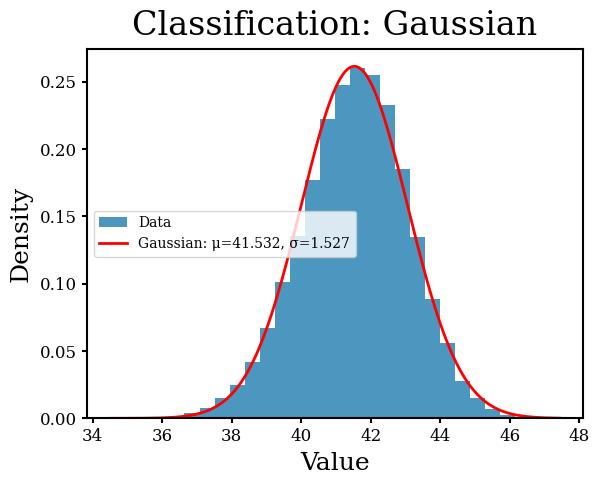

& Eqn 1
& 41.53 ± 1.53 \\
[[41.531799304184645]] [[1.52671065605663]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector1_phi_distributions.npz
u42 1
[[[26.277376899931237 24.824120138756765 22.5964633682025 ...
   40.94799766581001 37.61904189379164 40.84220733590059]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: 0.662, Mean: 40.829, Std: 18.065, Mu0: 40.829, Sigma0: 18.065, Mu1: 41.038, Sigma1: 18.347
skewness:  0.6615988123990331


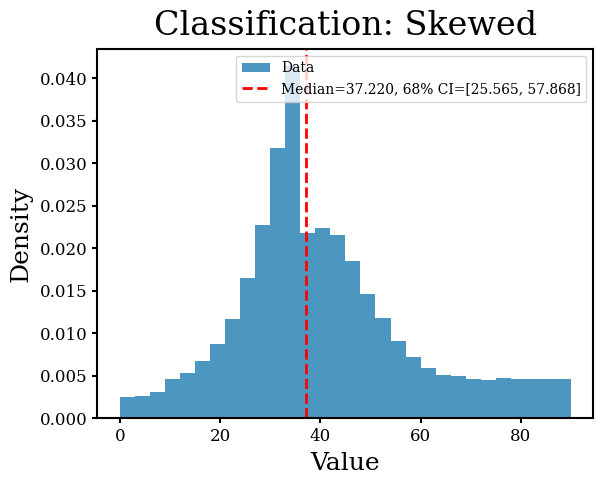

& Eqn 1
& 37.22_{-11.66}^{+20.65} \\
[[37.22012636766458]] [[[11.65508630093029, 20.64824622761114]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector2_phi_distributions.npz
u42 2
[[[22.3046809633564 6.039935250809931 20.859851311593264 ...
   1.1458987972327968 1.957148853652019 1.2845987295926518]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.125, Mean: 19.055, Std: 9.720, Mu0: 19.055, Sigma0: 9.720, Mu1: 19.055, Sigma1: 9.720
skewness:  -0.12512114499207924


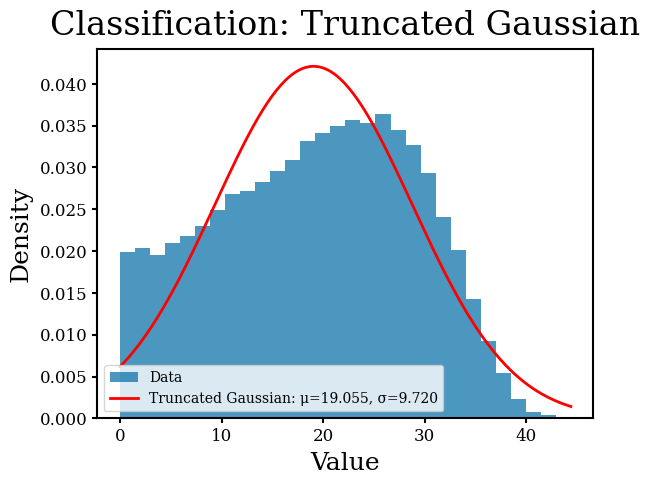

& Eqn 1
& 19.05 ± 9.72 \\
[[19.05473353669629]] [[9.7195020013708]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector3_phi_distributions.npz
u42 3
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector4_phi_distributions.npz
u42 4
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector5_phi_distributions.npz
u42 5
[[[26.117961403197235 32.11145554348315 27.928443926063764 ...
   31.802485491316464 27.523655800570822 25.557748795433866]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.892, Mean: 28.799, Std: 3.786, Mu0: 28.799, Sigma0: 3.786, Mu1: 28.799, Sigma1: 3.786
skewness:  -0.8915772078227895


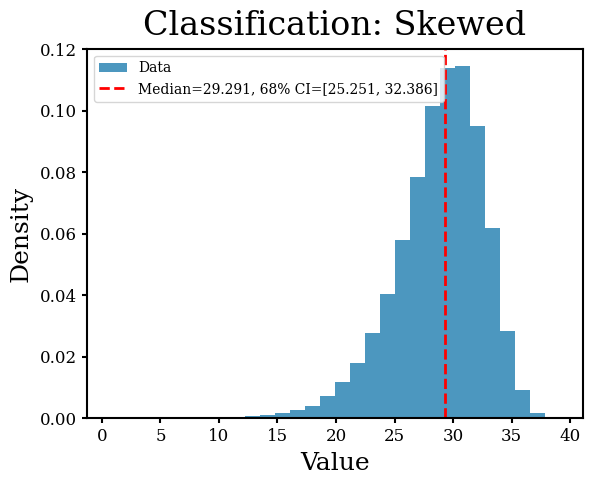

& Eqn 1
& 29.29_{-4.04}^{+3.09} \\
[[29.29117306291802]] [[[4.0397856927502005, 3.0949062037142028]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector6_phi_distributions.npz
u42 6
[[[36.548390519463126 36.549792293014136 32.99886655364953 ...
   33.302093406137764 36.34186817582072 32.93769610831652]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.529, Mean: 34.137, Std: 2.224, Mu0: 34.137, Sigma0: 2.224, Mu1: 34.137, Sigma1: 2.224
skewness:  -0.5286929820699974


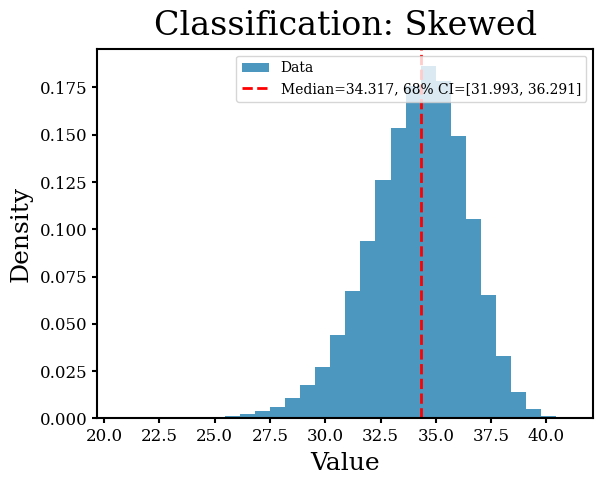

& Eqn 1
& 34.32_{-2.32}^{+1.97} \\
[[34.3168219627026]] [[[2.323838185500808, 1.9740767018530931]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector7_phi_distributions.npz
u42 7
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector8_phi_distributions.npz
u42 8
[[[33.206895246526905 30.035321134530555 28.15493125145744 ...
   30.34028859927958 35.47166877092053 34.60647931384693]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.818, Mean: 32.704, Std: 3.179, Mu0: 32.704, Sigma0: 3.179, Mu1: 32.704, Sigma1: 3.179
skewness:  -0.8181064355322721


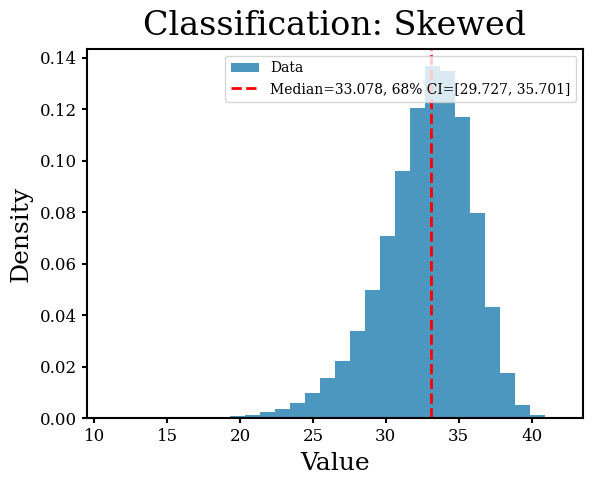

& Eqn 1
& 33.08_{-3.35}^{+2.62} \\
[[33.07809582114727]] [[[3.3512160725156477, 2.6228512918139515]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u42/mcmc/subsector9_phi_distributions.npz
u42 9
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector0_phi_distributions.npz
u43 0
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector1_phi_distributions.npz
u43 1
[[[38.58415970976506 37.5059101636984 37.468731576420204 ...
   41.125285195026784 33.6052697376675 39.19963179210572]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -1.043, Mean: 35.246, Std: 3.963, Mu0: 35.246, Sigma0: 3.963, Mu1: 35.246, Sigma1: 3.963
skewness:  -1.0431438032143054


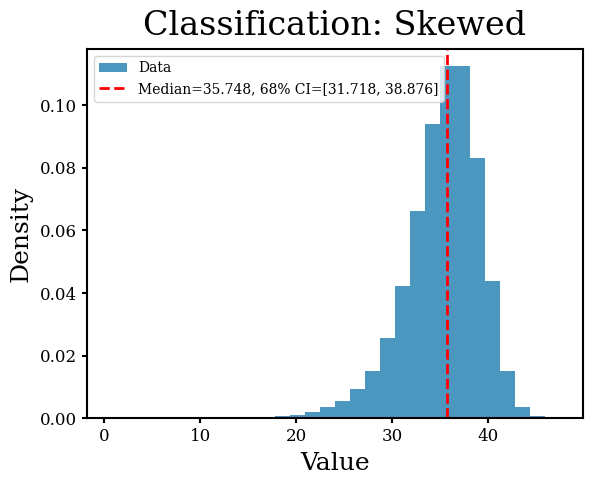

& Eqn 1
& 35.75_{-4.03}^{+3.13} \\
[[35.747895638383056]] [[[4.03002168754594, 3.128501015585776]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector2_phi_distributions.npz
u43 2
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector3_phi_distributions.npz
u43 3
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector4_phi_distributions.npz
u43 4
[[[59.09097676097166 87.0901129739112 60.66340943498191 ...
   73.95932973955006 61.42213265241056 79.28495628120118]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.100, Mean: 72.885, Std: 10.029, Mu0: 72.885, Sigma0: 10.029, Mu1: 75.575, Sigma1: 12.109
skewness:  -0.1003141636000134


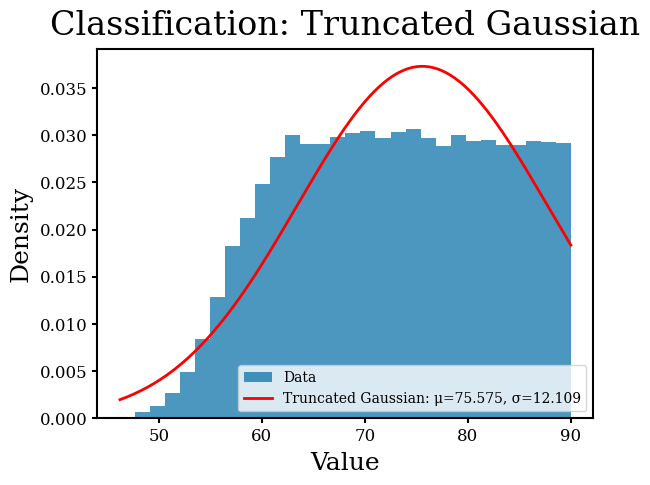

& Eqn 1
& 75.58 ± 12.11 \\
[[75.57544037115824]] [[12.109361401799521]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector5_phi_distributions.npz
u43 5
[[[66.00123574307551 58.94130587245039 50.77924680736814 ...
   50.541998608934776 51.50724165954162 69.3507087905878]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: 0.661, Mean: 62.310, Std: 12.364, Mu0: 62.310, Sigma0: 12.364, Mu1: 62.921, Sigma1: 13.031
skewness:  0.6613222986058869


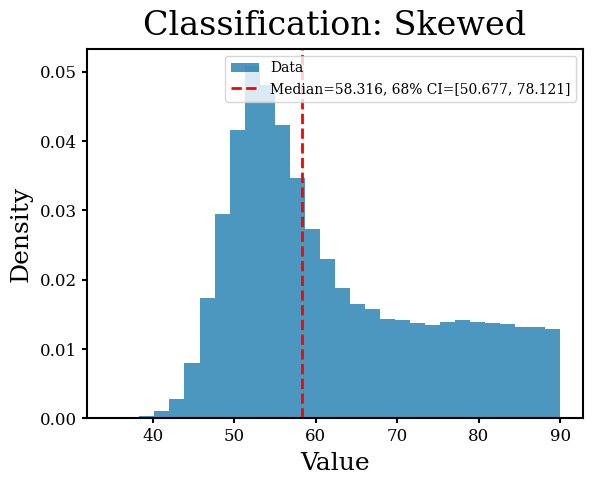

& Eqn 1
& 58.32_{-7.64}^{+19.80} \\
[[58.315678229750816]] [[[7.638535613509298, 19.804838370791757]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector6_phi_distributions.npz
u43 6
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector7_phi_distributions.npz
u43 7
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector8_phi_distributions.npz
u43 8
[[[39.27670630319502 39.17791284977584 38.418253415513234 ...
   36.477263973691706 36.716462386025775 40.02329904142271]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.269, Mean: 38.835, Std: 1.350, Mu0: 38.835, Sigma0: 1.350, Mu1: 38.835, Sigma1: 1.350
skewness:  -0.2690698719329018


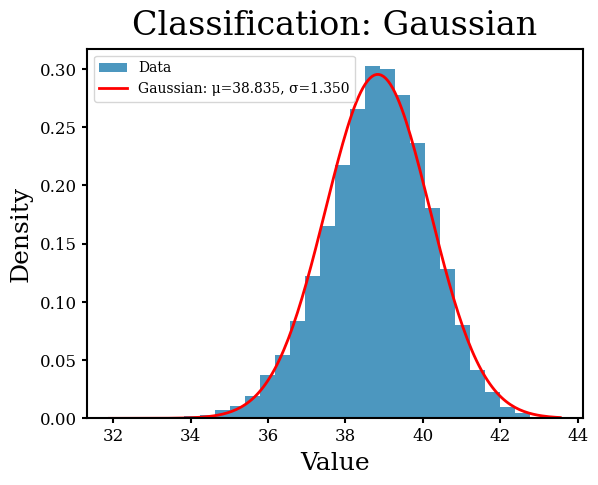

& Eqn 1
& 38.84 ± 1.35 \\
[[38.83539193333025]] [[1.3503227784674647]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u43/mcmc/subsector9_phi_distributions.npz
u43 9
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector0_phi_distributions.npz
u44 0
[[[43.4061379355115 40.464274688089596 43.01912267903619 ...
   39.162730489230164 45.37570046080741 41.28550802355557]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.130, Mean: 42.798, Std: 1.969, Mu0: 42.798, Sigma0: 1.969, Mu1: 42.798, Sigma1: 1.969
skewness:  -0.1297279596929721


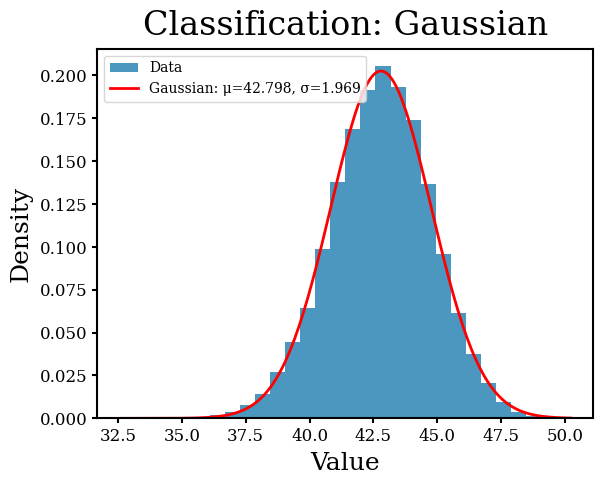

& Eqn 1
& 42.80 ± 1.97 \\
[[42.798303086018386]] [[1.9691904088345304]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector1_phi_distributions.npz
u44 1
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector2_phi_distributions.npz
u44 2
[[[33.445378314595466 21.11966515884696 27.062599668572254 ...
   32.21723186995085 33.85939297361109 6.762565504601382]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.914, Mean: 27.317, Std: 8.407, Mu0: 27.317, Sigma0: 8.407, Mu1: 27.317, Sigma1: 8.407
skewness:  -0.914379142784188


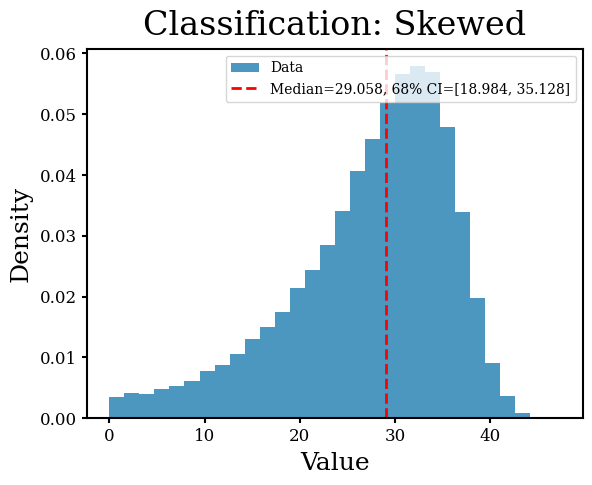

& Eqn 1
& 29.06_{-10.07}^{+6.07} \\
[[29.057796296269323]] [[[10.073747991187577, 6.0701734253193464]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector3_phi_distributions.npz
u44 3
[[array([50.00262138, 49.22104887, 54.20766093, ..., 72.28433715,
         76.91000174, 56.33897826])
  array([88.11040174, 87.530338  , 85.2801539 , ..., 89.09921828,
         88.37107785, 77.94484219])                              ]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: 1.366, Mean: 56.890, Std: 11.339, Mu0: 56.890, Sigma0: 11.339, Mu1: 56.960, Sigma1: 11.442
skewness:  1.3657332227650638


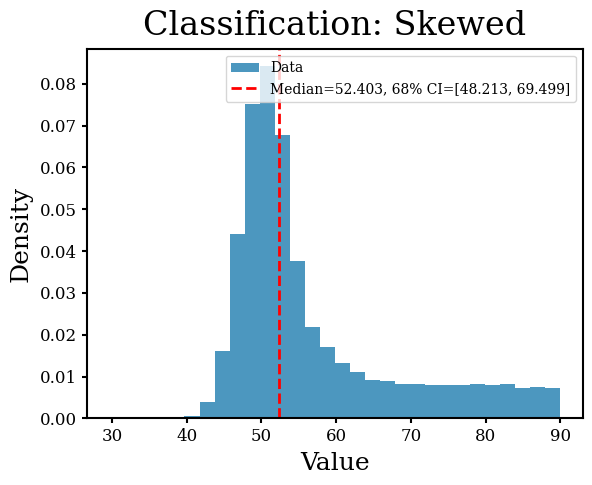

Skewness: -1.768, Mean: 85.564, Std: 4.477, Mu0: 85.564, Sigma0: 4.477, Mu1: 420.692, Sigma1: 38.809
skewness:  -1.7684050826254603


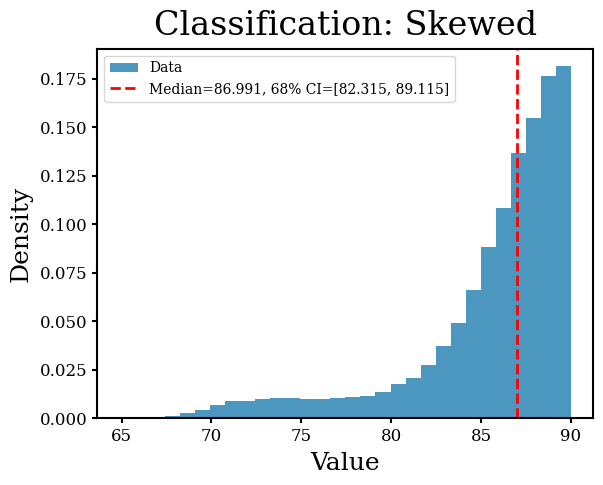

& Eqn 1
& 52.40_{-4.19}^{+17.10} \\
& 86.99_{-4.68}^{+2.12} \\
[[52.403278563852766, 86.991022372087]] [[[4.190144065820746, 17.09556148431119], [4.675692628852161, 2.124122276916694]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector4_phi_distributions.npz
u44 4
[]
Processing Wind Equation: sromovsky2012_odd_N
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector5_phi_distributions.npz
u44 5
[[[37.96965533630314 37.864379636263834 41.089678915316654 ...
   39.45201922736464 34.47068677778457 41.13900645342978]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.492, Mean: 38.265, Std: 2.427, Mu0: 38.265, Sigma0: 2.427, Mu1: 38.265, Sigma1: 2.427
skewness:  -0.49239287081333105


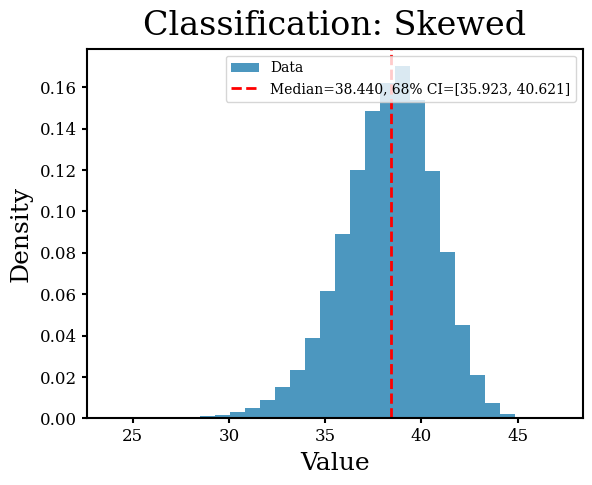

& Eqn 1
& 38.44_{-2.52}^{+2.18} \\
[[38.44044362882597]] [[[2.517108861609678, 2.1803961708943405]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector6_phi_distributions.npz
u44 6
[[[50.838392495873975 51.04107227574188 57.325188798071984 ...
   53.19822461791892 48.42431915849577 54.554044848630625]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: 3.611, Mean: 52.425, Std: 3.722, Mu0: 52.425, Sigma0: 3.722, Mu1: 52.425, Sigma1: 3.722
skewness:  3.611406822041894


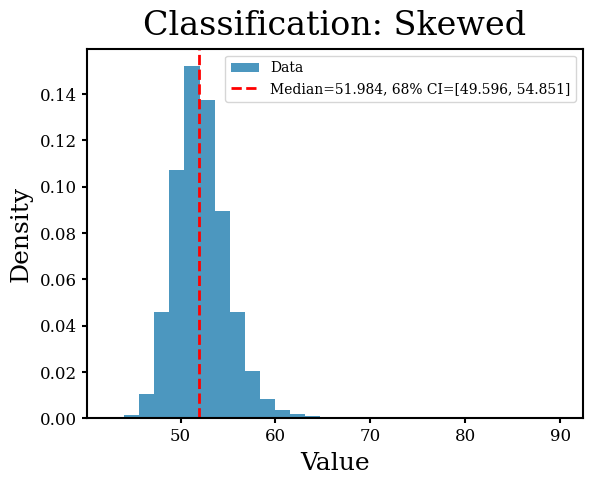

& Eqn 1
& 51.98_{-2.39}^{+2.87} \\
[[51.98390633167115]] [[[2.387821454107417, 2.866783496787775]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector7_phi_distributions.npz
u44 7
[[[19.5629403891905 23.972720927549094 7.939302461612294 ...
   21.795848691798742 9.471695207960803 18.08607797838434]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.663, Mean: 19.169, Std: 5.873, Mu0: 19.169, Sigma0: 5.873, Mu1: 19.169, Sigma1: 5.873
skewness:  -0.6628055022526574


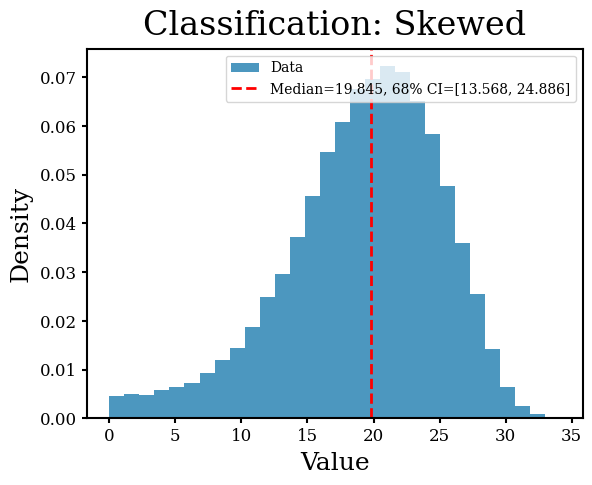

& Eqn 1
& 19.84_{-6.28}^{+5.04} \\
[[19.844796218048884]] [[[6.276872241011578, 5.040939813008428]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector8_phi_distributions.npz
u44 8
[[[62.89905717870236 72.28688159482675 62.28428081254144 ...
   88.99639320673576 82.94271383674706 88.67836398799248]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.296, Mean: 78.852, Std: 7.325, Mu0: 78.852, Sigma0: 7.325, Mu1: 82.763, Sigma1: 9.862
skewness:  -0.2956898455570861


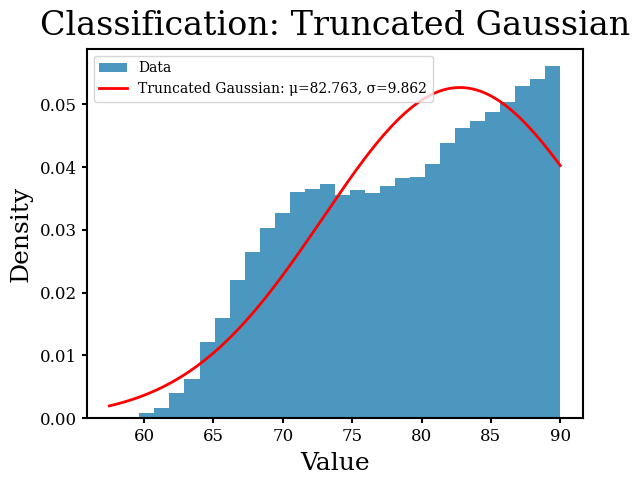

& Eqn 1
& 82.76 ± 9.86 \\
[[82.76304256385684]] [[9.862057495626052]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/u44/mcmc/subsector9_phi_distributions.npz
u44 9
[[[40.10717637080924 42.44651238095133 22.218338676421922 ...
   39.24469446247039 42.62247797012364 36.721920222986626]]]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -1.185, Mean: 36.027, Std: 4.629, Mu0: 36.027, Sigma0: 4.629, Mu1: 36.027, Sigma1: 4.629
skewness:  -1.185087441325113


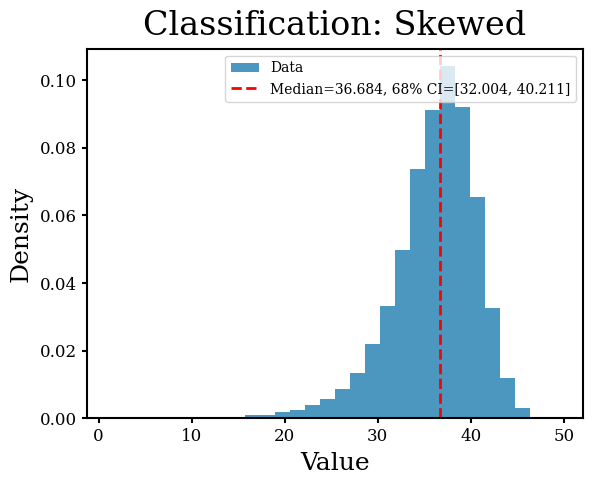

& Eqn 1
& 36.68_{-4.68}^{+3.53} \\
[[36.68417857021372]] [[[4.680107683478127, 3.52639612471382]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector0_phi_distributions.npz
n42 0
[]
Processing Wind Equation: sromovsky1993_four
& Eqn 1
[[]] [[]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector1_phi_distributions.npz
n42 1
[[[64.08954535145634 64.89265320802616 66.48642363545865 ...
   68.38831998792854 67.68068485231694 68.506142698875]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.272, Mean: 66.728, Std: 1.269, Mu0: 66.728, Sigma0: 1.269, Mu1: 66.728, Sigma1: 1.269
skewness:  -0.2718425053763519


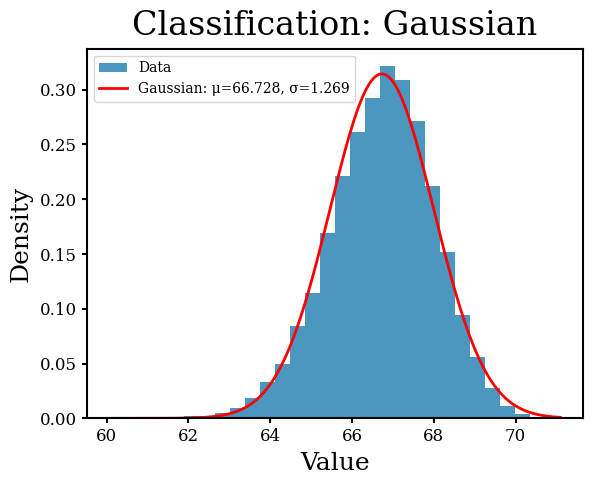

& Eqn 1
& 66.73 ± 1.27 \\
[[66.72789610873943]] [[1.2688874756253812]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector2_phi_distributions.npz
n42 2
[[[60.56607010455938 60.60389431002997 62.77520597731639 ...
   61.1265655765901 59.61769555679715 61.00548210840282]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.174, Mean: 61.079, Std: 1.526, Mu0: 61.079, Sigma0: 1.526, Mu1: 61.079, Sigma1: 1.526
skewness:  -0.17364059364338136


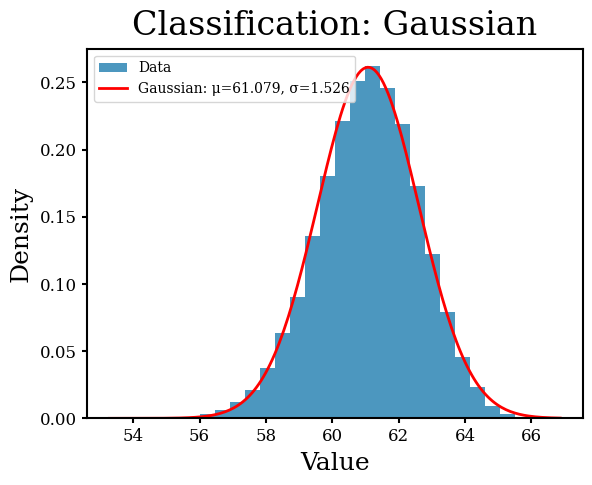

& Eqn 1
& 61.08 ± 1.53 \\
[[61.07927891480865]] [[1.5264615111053046]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector3_phi_distributions.npz
n42 3
[[[66.59114144885706 67.27817941006651 64.16142210017132 ...
   67.35060049961041 68.84877566198298 64.21267831466876]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.315, Mean: 65.562, Std: 1.786, Mu0: 65.562, Sigma0: 1.786, Mu1: 65.562, Sigma1: 1.786
skewness:  -0.3153266849710715


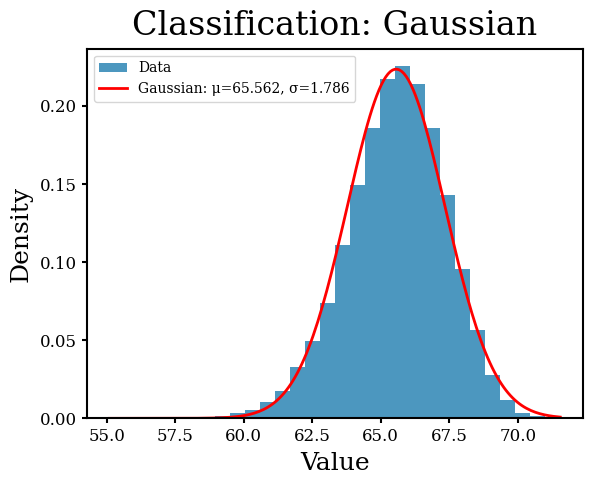

& Eqn 1
& 65.56 ± 1.79 \\
[[65.56178685527428]] [[1.7855939559573015]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector4_phi_distributions.npz
n42 4
[[[24.395437012292202 20.56385962329982 1.875049793717546 ...
   45.067458366974655 45.8747877621481 40.828803495328714]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -1.010, Mean: 33.307, Std: 11.042, Mu0: 33.307, Sigma0: 11.042, Mu1: 33.307, Sigma1: 11.042
skewness:  -1.0100868208528968


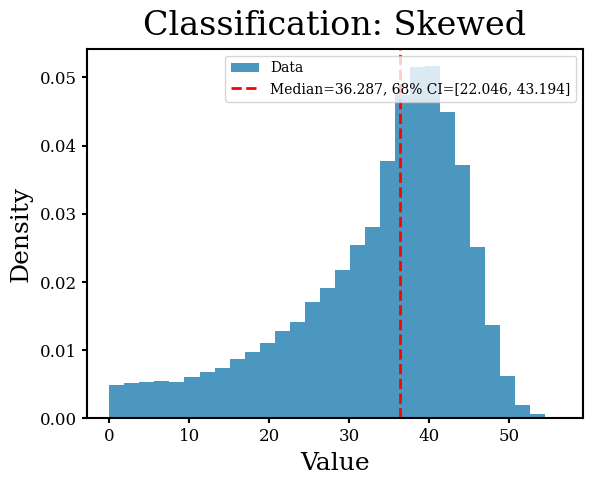

& Eqn 1
& 36.29_{-14.24}^{+6.91} \\
[[36.28650080147802]] [[[14.24055586011902, 6.907162078319608]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector5_phi_distributions.npz
n42 5
[[[56.83137550028355 53.19606383443874 53.950926228948916 ...
   54.674689267779954 56.283418761266 54.28824950261953]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.143, Mean: 53.464, Std: 1.439, Mu0: 53.464, Sigma0: 1.439, Mu1: 53.464, Sigma1: 1.439
skewness:  -0.142904574369996


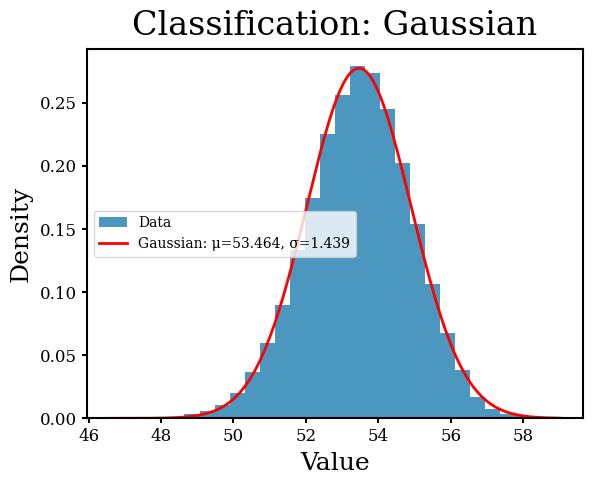

& Eqn 1
& 53.46 ± 1.44 \\
[[53.46421500304338]] [[1.4390300109639103]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector6_phi_distributions.npz
n42 6
[[[52.87285512624293 50.38569224335165 50.751374090553 ...
   51.747783776265294 47.902376572017424 50.524620644754776]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.158, Mean: 50.949, Std: 1.575, Mu0: 50.949, Sigma0: 1.575, Mu1: 50.949, Sigma1: 1.575
skewness:  -0.1584056092511998


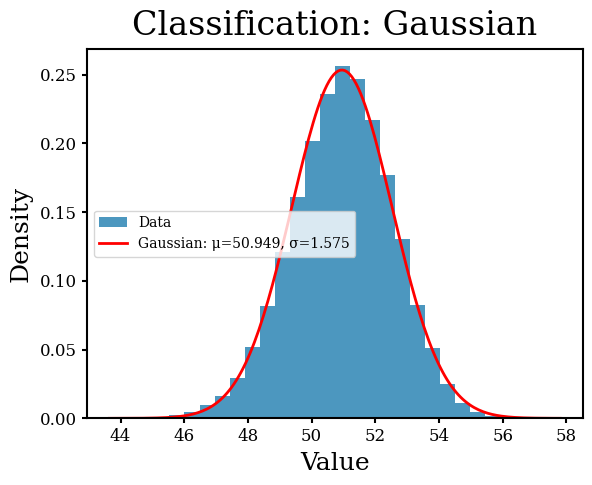

& Eqn 1
& 50.95 ± 1.57 \\
[[50.94904405872547]] [[1.574894064869724]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector7_phi_distributions.npz
n42 7
[[[52.9635770380597 52.58635409587592 53.0885174292298 ...
   52.51057374314583 50.97669384293459 52.841263369313026]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.088, Mean: 52.431, Std: 1.269, Mu0: 52.431, Sigma0: 1.269, Mu1: 52.431, Sigma1: 1.269
skewness:  -0.08825741280157251


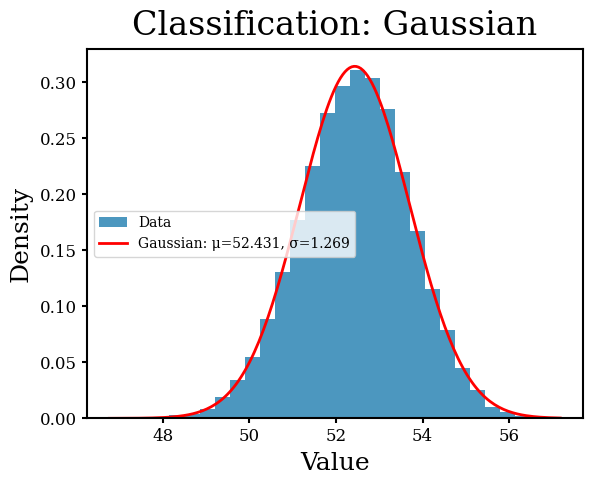

& Eqn 1
& 52.43 ± 1.27 \\
[[52.43107268204195]] [[1.2687025005854402]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector8_phi_distributions.npz
n42 8
[[[45.427893242707 41.852485589238334 40.971592914416206 ...
   40.684603726947934 23.86698282801583 36.707677490217094]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.869, Mean: 38.066, Std: 5.613, Mu0: 38.066, Sigma0: 5.613, Mu1: 38.066, Sigma1: 5.613
skewness:  -0.86911631044049


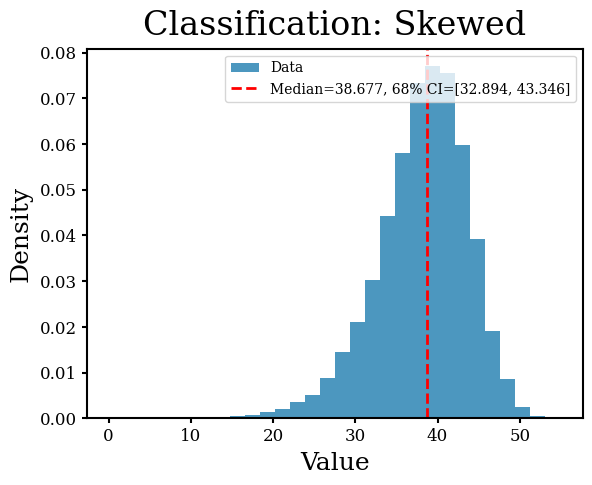

& Eqn 1
& 38.68_{-5.78}^{+4.67} \\
[[38.67730691959517]] [[[5.7831958602159546, 4.669130663111424]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n42/mcmc/subsector9_phi_distributions.npz
n42 9
[[[81.6623529820174 58.72178368208388 59.98363292678818 ...
   70.50471167817902 75.45515634056862 82.46848589670182]]]
Processing Wind Equation: sromovsky1993_four
Skewness: 0.082, Mean: 70.106, Std: 7.545, Mu0: 70.106, Sigma0: 7.545, Mu1: 70.219, Sigma1: 7.692
skewness:  0.08231841872162986


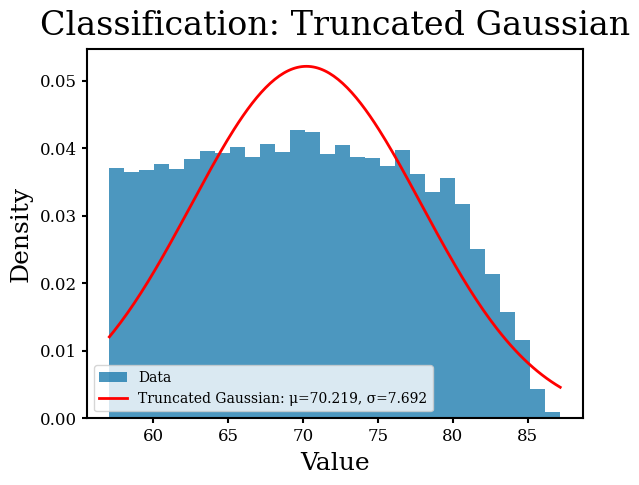

& Eqn 1
& 70.22 ± 7.69 \\
[[70.21860635401417]] [[7.692309526426792]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector0_phi_distributions.npz
n70 0
[[[3.1084156215144714 22.210733872796375 12.13183958773497 ...
   17.427294750867297 13.517148839110659 16.050078310422432]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.745, Mean: 16.124, Std: 5.153, Mu0: 16.124, Sigma0: 5.153, Mu1: 16.124, Sigma1: 5.153
skewness:  -0.7446619461201137


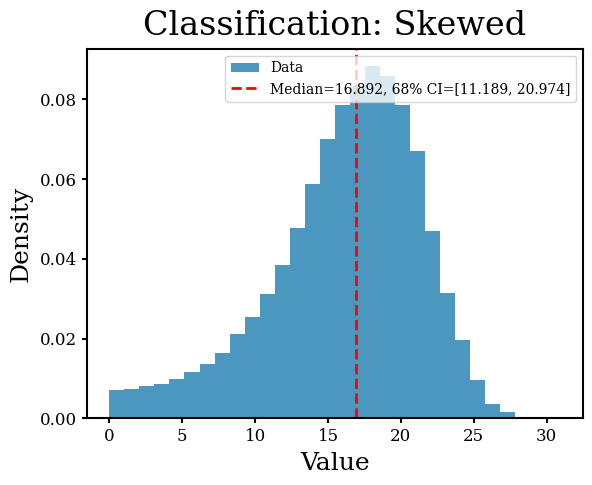

& Eqn 1
& 16.89_{-5.70}^{+4.08} \\
[[16.89221169430791]] [[[5.703651230879581, 4.082042997545255]]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector1_phi_distributions.npz
n70 1
[[[58.43807164062489 57.24795305259315 57.753571417092246 ...
   56.83487759051582 58.38532202732872 58.34575308638289]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.043, Mean: 56.843, Std: 0.946, Mu0: 56.843, Sigma0: 0.946, Mu1: 56.843, Sigma1: 0.946
skewness:  -0.042529022837546844


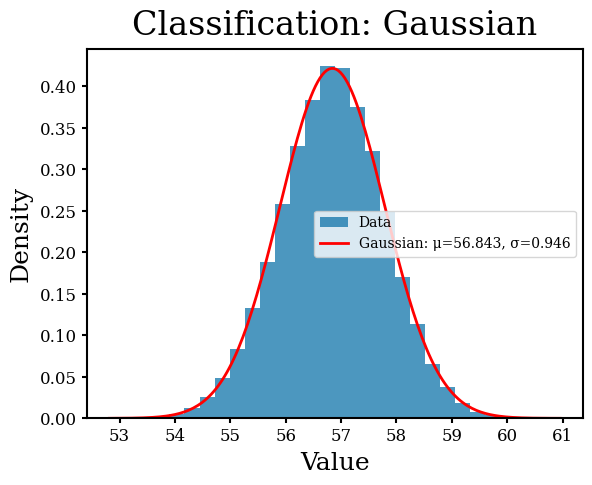

& Eqn 1
& 56.84 ± 0.95 \\
[[56.84316773958954]] [[0.9456745595385704]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector2_phi_distributions.npz
n70 2
[[[25.24419772270309 18.959249077122255 23.220463814339134 ...
   24.256637187480678 18.849990660881627 20.926981309441356]
  [78.08793247358125 77.32708898334049 78.0032388961645 ...
   77.5696683044936 76.79473430337215 77.63669458576217]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.886, Mean: 21.089, Std: 3.812, Mu0: 21.089, Sigma0: 3.812, Mu1: 21.089, Sigma1: 3.812
skewness:  -0.886106088330985


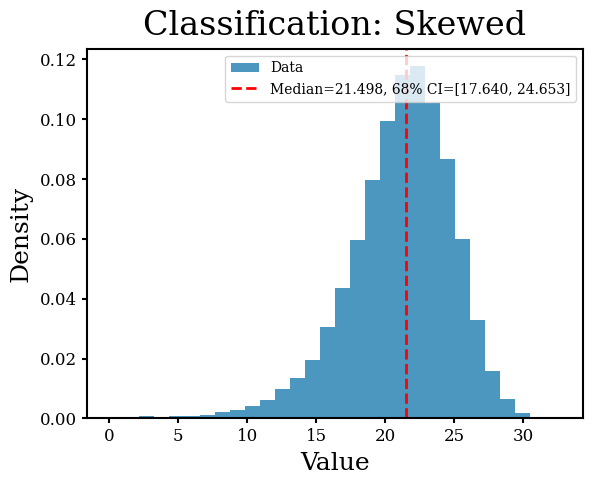

Skewness: -0.225, Mean: 77.434, Std: 0.740, Mu0: 77.434, Sigma0: 0.740, Mu1: 77.434, Sigma1: 0.740
skewness:  -0.22530504131610693


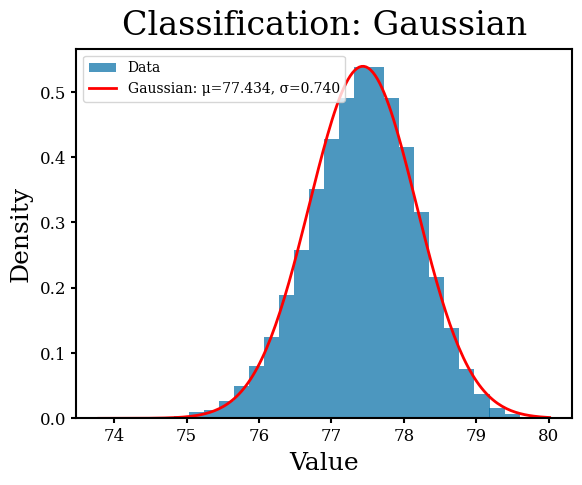

& Eqn 1
& 21.50_{-3.86}^{+3.16} \\
& 77.43 ± 0.74 \\
[[21.49771824307963, 77.43371832330126]] [[[3.8572410441620555, 3.155585901045246], 0.7398056786711191]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector3_phi_distributions.npz
n70 3
[[[45.514198635952724 42.70415317299565 44.47473334742641 ...
   44.00106818846387 46.551322851790054 41.37372210408158]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.251, Mean: 43.987, Std: 2.272, Mu0: 43.987, Sigma0: 2.272, Mu1: 43.987, Sigma1: 2.272
skewness:  -0.25062737570401883


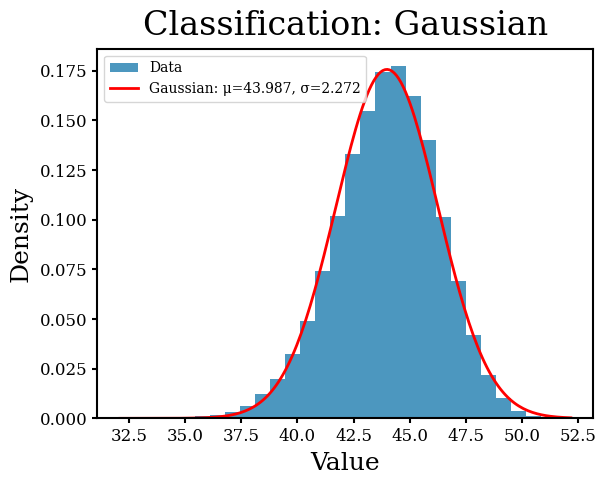

& Eqn 1
& 43.99 ± 2.27 \\
[[43.987296617515014]] [[2.2718196745413834]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector4_phi_distributions.npz
n70 4
[[[39.31915388211251 38.96976209683012 39.21822495165401 ...
   39.508303155013685 35.59457436108304 38.57085269561928]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.131, Mean: 37.886, Std: 1.591, Mu0: 37.886, Sigma0: 1.591, Mu1: 37.886, Sigma1: 1.591
skewness:  -0.13073122615499266


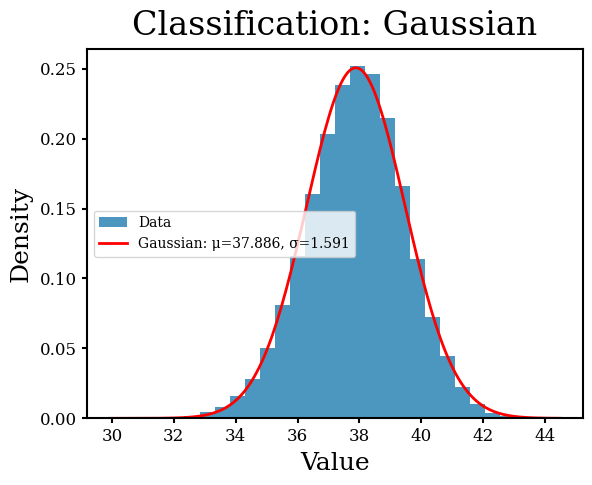

& Eqn 1
& 37.89 ± 1.59 \\
[[37.88634541301953]] [[1.5913668999035226]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector5_phi_distributions.npz
n70 5
[[[59.25323903238468 58.46071950649273 59.54603715861958 ...
   60.030721132994415 59.378664408791764 59.21364059114389]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.107, Mean: 59.712, Std: 1.165, Mu0: 59.712, Sigma0: 1.165, Mu1: 59.712, Sigma1: 1.165
skewness:  -0.1072698605718387


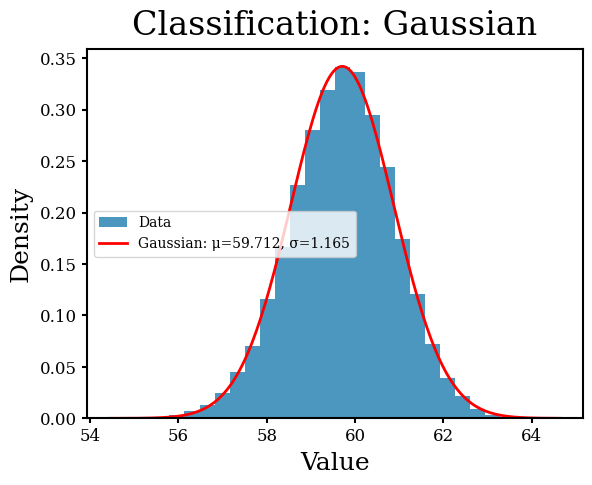

& Eqn 1
& 59.71 ± 1.17 \\
[[59.7115454374712]] [[1.1654758331276855]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector6_phi_distributions.npz
n70 6
[[[50.514728591247376 50.90619354359975 51.38962155663765 ...
   51.23424813606159 50.110593604035216 49.7245175977898]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.015, Mean: 50.566, Std: 1.013, Mu0: 50.566, Sigma0: 1.013, Mu1: 50.566, Sigma1: 1.013
skewness:  -0.015387898748471697


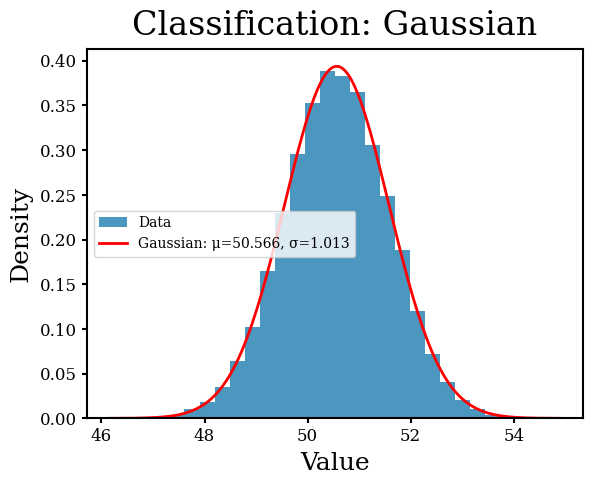

& Eqn 1
& 50.57 ± 1.01 \\
[[50.56591554767684]] [[1.0130071446003088]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector7_phi_distributions.npz
n70 7
[[[49.86009893272055 49.17387900401365 48.92562693246304 ...
   49.39006121595948 48.67812553791329 47.69615296482625]
  [76.56007684099565 76.99304573251244 77.55044905479966 ...
   76.84660825831962 76.87045604227558 76.28145284463217]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.015, Mean: 49.470, Std: 1.013, Mu0: 49.470, Sigma0: 1.013, Mu1: 49.470, Sigma1: 1.013
skewness:  -0.015346764400722898


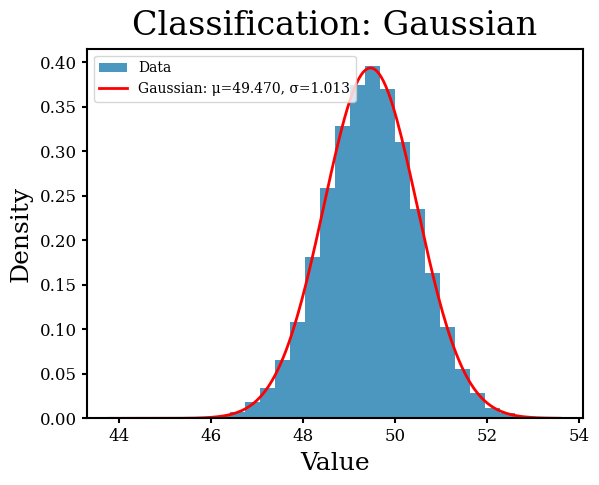

Skewness: -0.066, Mean: 76.695, Std: 0.524, Mu0: 76.695, Sigma0: 0.524, Mu1: 76.695, Sigma1: 0.524
skewness:  -0.06608329279455478


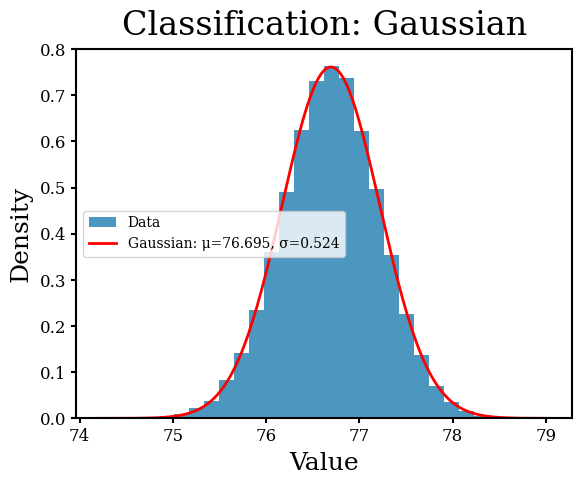

& Eqn 1
& 49.47 ± 1.01 \\
& 76.70 ± 0.52 \\
[[49.470323924414316, 76.69504588361515]] [[1.0133514273052762, 0.5239968550789813]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector8_phi_distributions.npz
n70 8
[[[27.463642268110114 28.30188737823629 26.20227967363111 ...
   25.53959792748736 27.518091707124913 29.646169909831308]
  [85.94100055659133 86.03988752286307 85.8460194259225 ...
   86.00187105376291 86.04782774722939 85.81001282649322]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.250, Mean: 26.495, Std: 2.399, Mu0: 26.495, Sigma0: 2.399, Mu1: 26.495, Sigma1: 2.399
skewness:  -0.2501629675604092


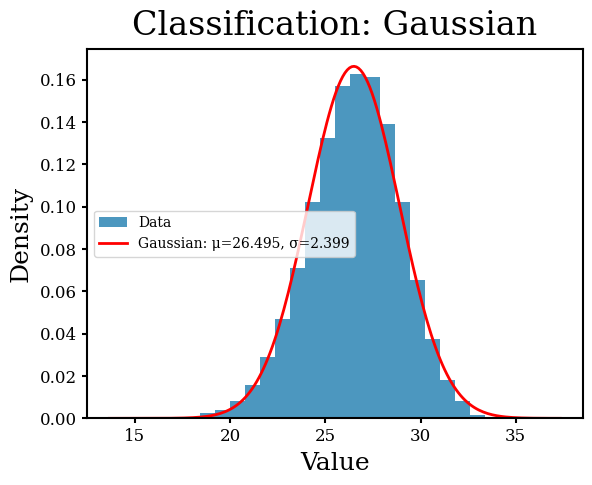

Skewness: -0.023, Mean: 86.028, Std: 0.148, Mu0: 86.028, Sigma0: 0.148, Mu1: 86.028, Sigma1: 0.148
skewness:  -0.023134750553792424


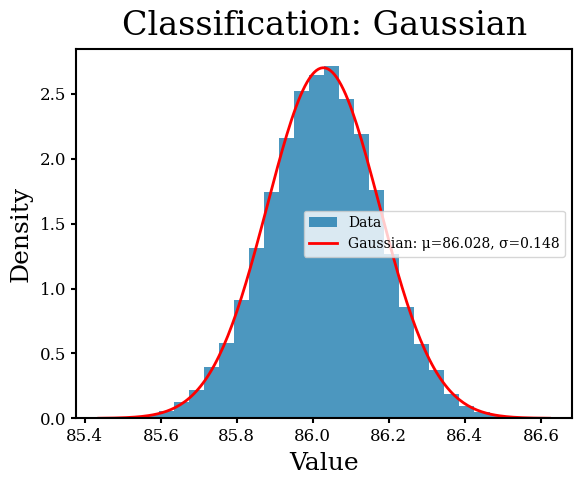

& Eqn 1
& 26.50 ± 2.40 \\
& 86.03 ± 0.15 \\
[[26.495193210680355, 86.02761101379618]] [[2.3992650645470035, 0.14773476006517444]]
/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/subsectors/n70/mcmc/subsector9_phi_distributions.npz
n70 9
[[[63.91286983392062 65.17163097204153 64.43038828934169 ...
   65.29639591625893 63.89122153060799 64.14937112027616]
  [78.884745837116 78.43713013224232 78.90589145549254 ...
   78.25182867604624 78.89428581298968 78.66977674130501]]]
Processing Wind Equation: sromovsky1993_four
Skewness: -0.015, Mean: 64.646, Std: 0.799, Mu0: 64.646, Sigma0: 0.799, Mu1: 64.646, Sigma1: 0.799
skewness:  -0.014799458666010606


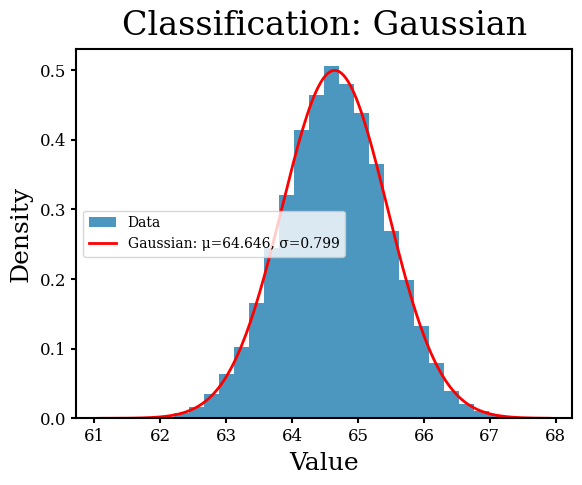

Skewness: -0.068, Mean: 78.450, Std: 0.481, Mu0: 78.450, Sigma0: 0.481, Mu1: 78.450, Sigma1: 0.481
skewness:  -0.0681458571421981


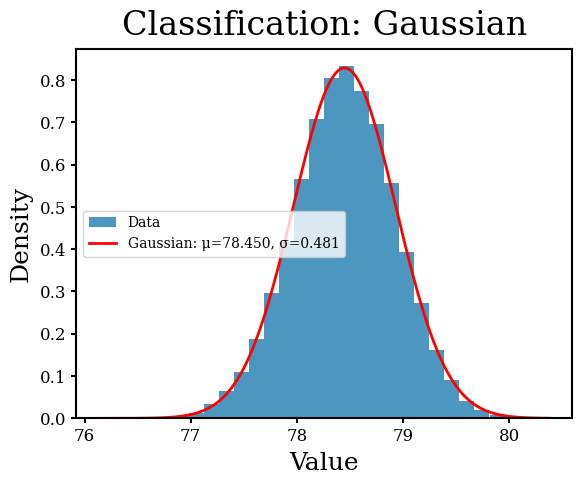

& Eqn 1
& 64.65 ± 0.80 \\
& 78.45 ± 0.48 \\
[[64.64604264210642, 78.44956714677761]] [[0.7986719762470881, 0.48147375790686026]]


In [6]:
import glob

from mcmc import fit_all_distributions

subroot = root + "subsectors"

print(root)
for sector in planet_sectors:
    secsubroot = subroot + "/" + sector
    mcmc_list = glob.glob(secsubroot + "/mcmc/*")
    mcmc_list.sort(key=lambda x: int(re.search(r'subsector(\d+)', x).group(1)))

    for i, phi_file in enumerate(mcmc_list):
        print(phi_file)
        print(sector, i)

        phi_dist = np.load(phi_file, allow_pickle=True)
        phi_data = phi_dist['phi_distributions']

        print(phi_data)
        # for data in phi_data:
        #     if len(data) > 0:
        #         print("mean, std", np.median(data), np.std(data))
        #     else:
        #         continue
        all_latitudes, all_standard_devs = fit_all_distributions(phi_dist["phi_distributions"], 
                                                                        phi_dist["wind_eqn_strings"], 
                                                                        plot=True, verbose=False, min_prominence=0.1, 
                                                                        skew_threshold=0.35)

        print(all_latitudes, all_standard_devs)

        if os.path.exists(secsubroot + "/latitudes/") == False:
            os.makedirs(secsubroot + "/latitudes/")
        np.savez(secsubroot + "/latitudes/" + f"{sector}_sub{i}_latitude_solutions.npz", 
                    lat=np.array(all_latitudes, dtype=object), 
                    std=np.array(all_standard_devs, dtype=object), 
                    allow_pickle=True) 
        # print(all_latitudes)
        # print(all_standard_devs)


In [13]:
for sector in planet_sectors:
    secsubroot = subroot + "/" + sector
    lat_list = glob.glob(secsubroot + "/latitudes/*")
    for i, phi_file in enumerate(lat_list):
        print(sector, i)

        phi_dist = np.load(phi_file, allow_pickle=True)
        print(phi_dist['lat'], phi_dist['std'])

u42 0
[] []
u42 1
[[34.30731967363759]] [[[2.3742508363030765 1.991689341633382]]]
u42 2
[[41.537020092796496]] [[1.5226602626631918]]
u42 3
[[18.955944724173115]] [[9.758552171219819]]
u42 4
[[37.22033777635266]] [[[11.521303821852545 21.86889103463085]]]
u42 5
[] []
u42 6
[[29.324300823600833]] [[[4.183288080528044 3.062459938470358]]]
u42 7
[] []
u42 8
[] []
u42 9
[[33.130977004641096]] [[[3.351386180837551 2.608330579070426]]]
u43 0
[[57.84166731528906]] [[[7.377855519927323 19.85443959555751]]]
u43 1
[] []
u43 2
[] []
u43 3
[] []
u43 4
[] []
u43 5
[[38.82780366154942]] [[1.3689514202966087]]
u43 6
[] []
u43 7
[[35.79977922575699]] [[[4.234809449175902 3.178826427066049]]]
u43 8
[[75.78001172828135]] [[12.250097470546946]]
u43 9
[] []
u44 0
[] []
u44 1
[[52.55450079233367 86.94731368508309]] [[[4.37426900903813 18.569258059218754]
  [5.065720413256045 2.1671392666419536]]]
u44 2
[[38.44361251288382]] [[[2.5201575326487102 2.2052538812970894]]]
u44 3
[[19.840631050821656]] [[[6.4476

In [51]:
def multiply_by_scalar(data, scalar):
    """Recursively multiply all numeric values by scalar"""
    if isinstance(data, (list, tuple)):
        return [multiply_by_scalar(item, scalar) for item in data]
    elif isinstance(data, np.ndarray):
        return data * scalar
    else:
        return data * scalar

cluster_results = cluster['cluster_results']
nsub = cluster_results.shape[1]
sec = 0
for sub in range(nsub):
    labels, all_means, all_stds = cluster_results[sec, sub]
    sector_data = {}
    sector_data['matched_means'] = []
    sector_data['matched_stds'] = []
    
    if len(all_means) > 0:
        sector_data['matched_means'].extend(all_means)
        sector_data['matched_stds'].extend(all_stds)

    # print(np.array(all_means), all_stds)

    result_means = multiply_by_scalar(all_means, 24)
    result_stds = multiply_by_scalar(all_stds, 24)

    print("Multiplied means:", result_means)
    print("Multiplied stds:", result_stds)
    print()

Multiplied means: [15.987467968302038]
Multiplied stds: [0.14925118695598547]

Multiplied means: [16.18600129617628]
Multiplied stds: [[0.5276940861449289, 1.2181798884927142]]

Multiplied means: [17.15586925855235]
Multiplied stds: [0.4208621162922763]

Multiplied means: [17.75953552788647]
Multiplied stds: [0.29377278806690066]

Multiplied means: []
Multiplied stds: []

Multiplied means: [16.896758165721543]
Multiplied stds: [0.17171303733340978]

Multiplied means: [16.61235230408225]
Multiplied stds: [0.15250781483739267]

Multiplied means: []
Multiplied stds: []

Multiplied means: [16.676399186426565]
Multiplied stds: [0.18641997091308704]

Multiplied means: []
Multiplied stds: []



In [8]:
print(subpower.shape)
for peakfap in subpeakfap:
    print(peakfap)

(5, 10, 1000)
[array([2.54280981e-52]), array([2.44304214e-38]), array([1.21741106e-68]), array([8.19540629e-19]), array([1.31907569e-06, 1.08077539e-34]), array([8.81024033e-46, 5.78632650e-28]), array([4.68879249e-10]), array([9.15178944e-26, 1.22359968e-15, 1.51908347e-02]), array([6.51285967e-42, 7.46501521e-04])]
[array([1.27036578e-127, 6.84435581e-008]), array([2.36666743e-23, 3.02541257e-36, 3.27150777e-03]), array([7.3658518e-12]), array([9.30554459e-29]), array([5.08882738e-68]), array([8.93964134e-70])]
[array([8.47144638e-08, 1.94692058e-02]), array([0.00234778]), array([7.11587534e-30]), array([7.91059409e-29, 3.38054589e-13, 1.56205423e-14]), array([8.05219561e-46, 3.03163858e-04]), array([1.00024424e-09, 2.88419705e-03]), array([3.37957300e-37, 1.76503083e-29]), array([7.25945927e-41, 1.59213926e-05]), array([3.02487150e-38, 1.01093168e-07]), array([5.1999974e-24])]
[array([5.07121474e-40]), array([4.56330098e-40]), array([9.34467714e-11]), array([3.47632673e-68, 8.23094

fap levep: 10
processing u42


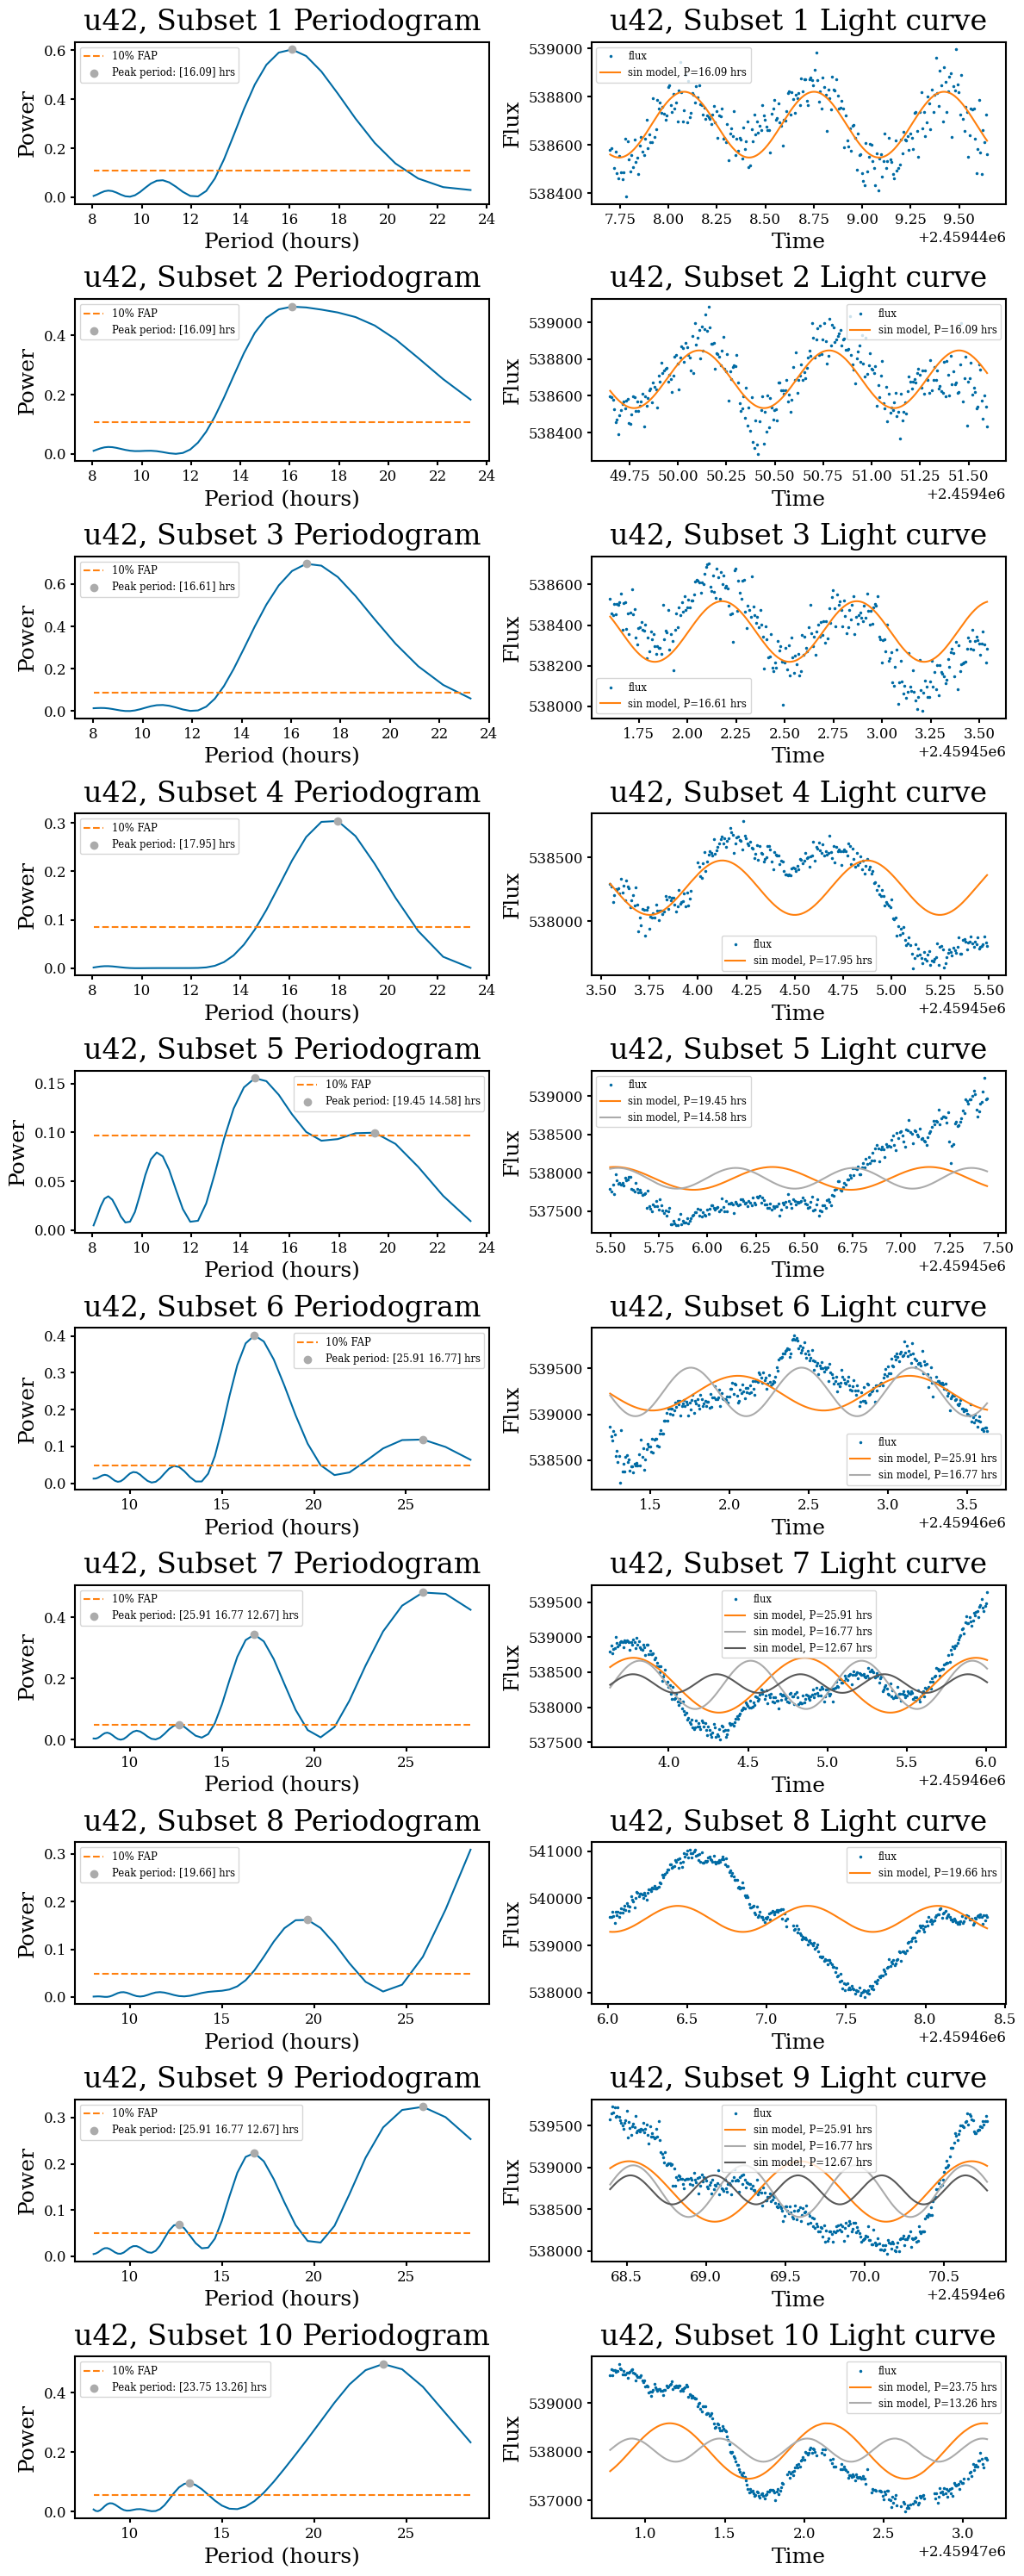

processing u43


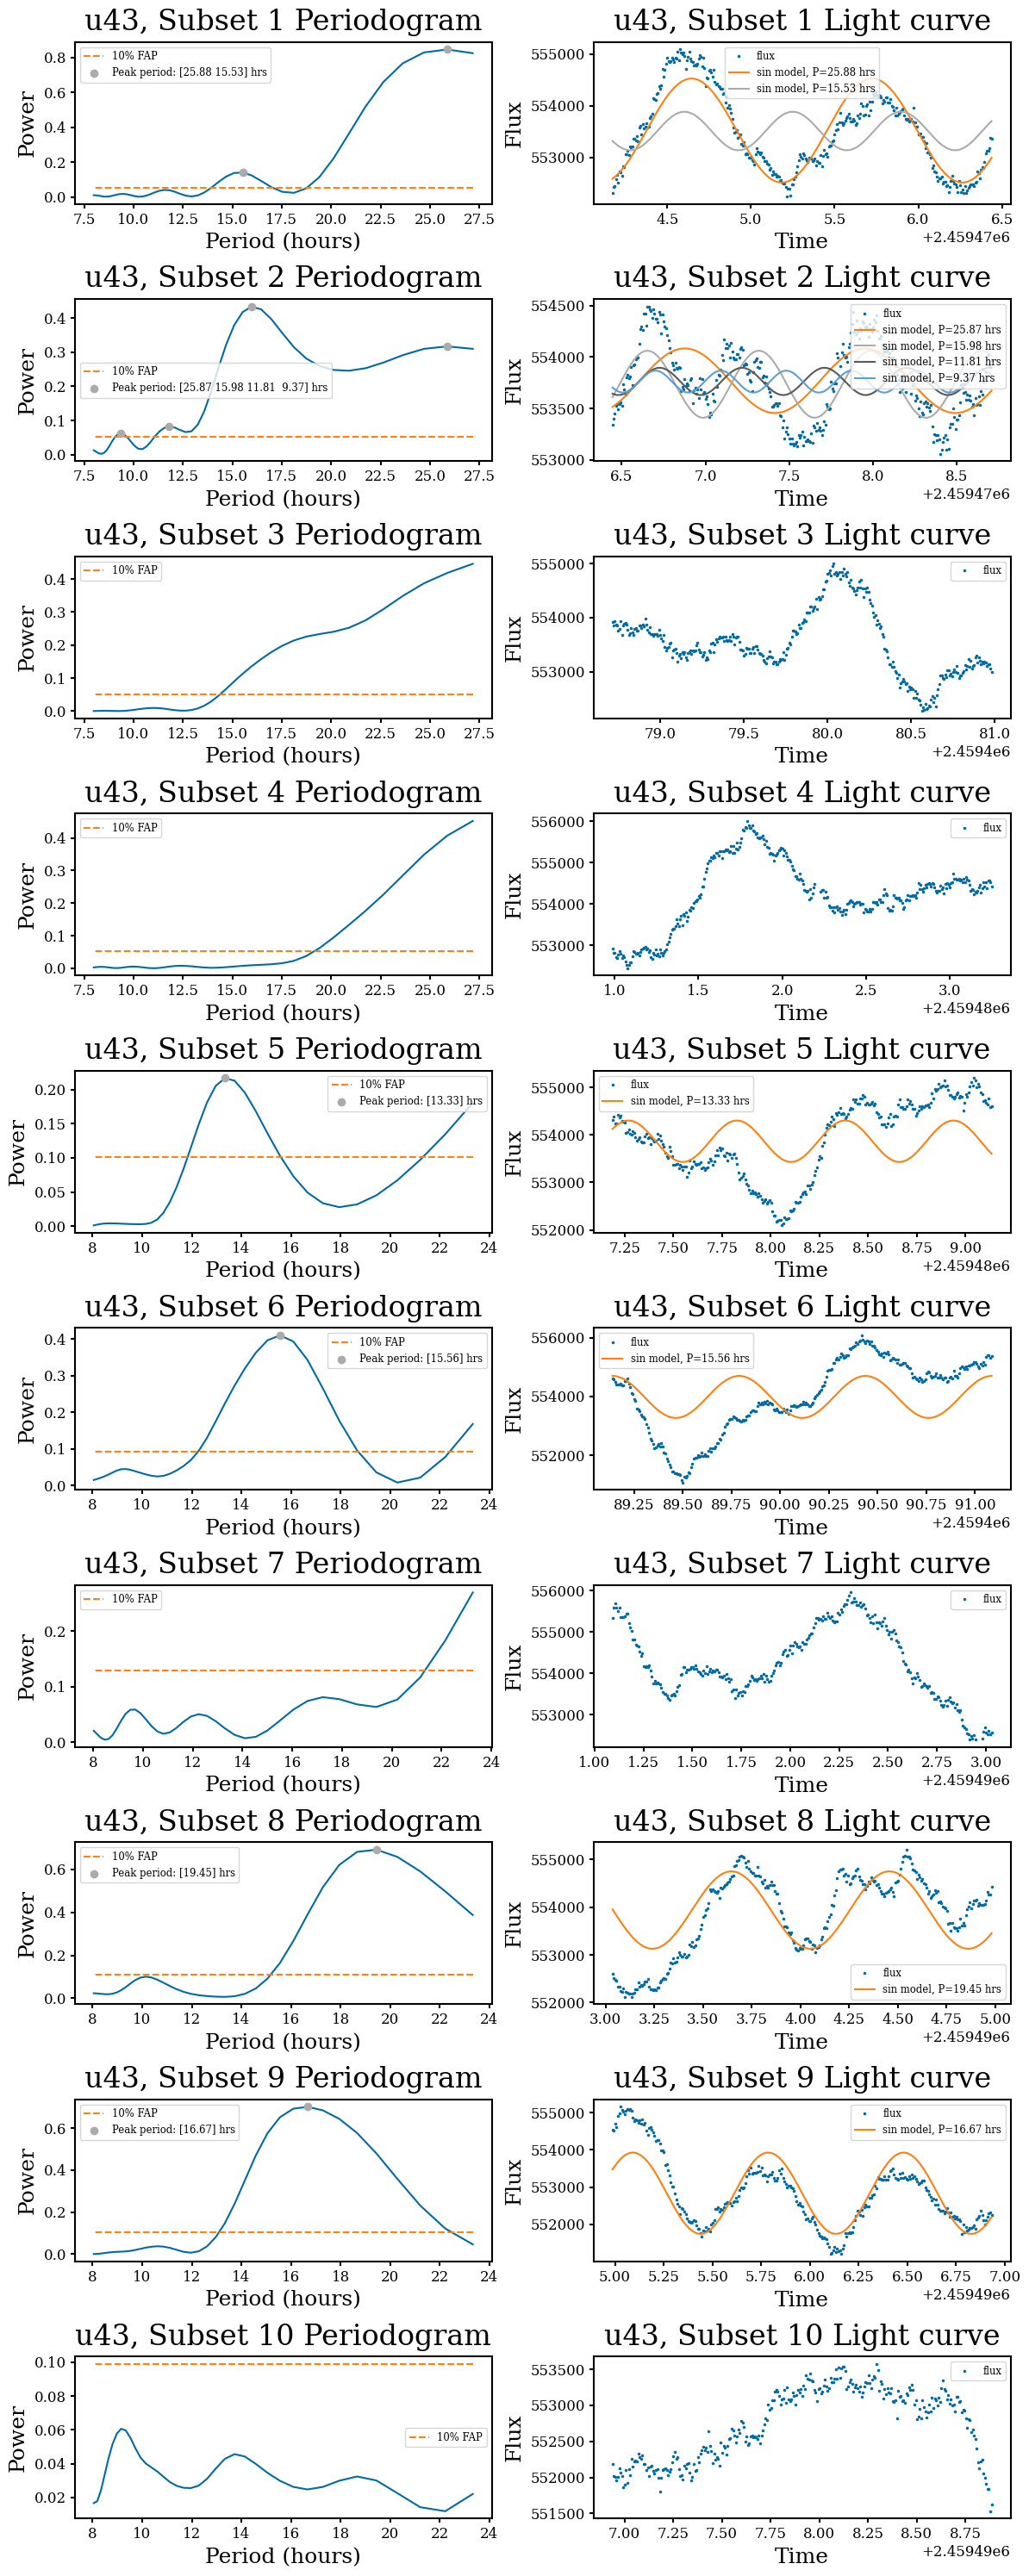

processing u44


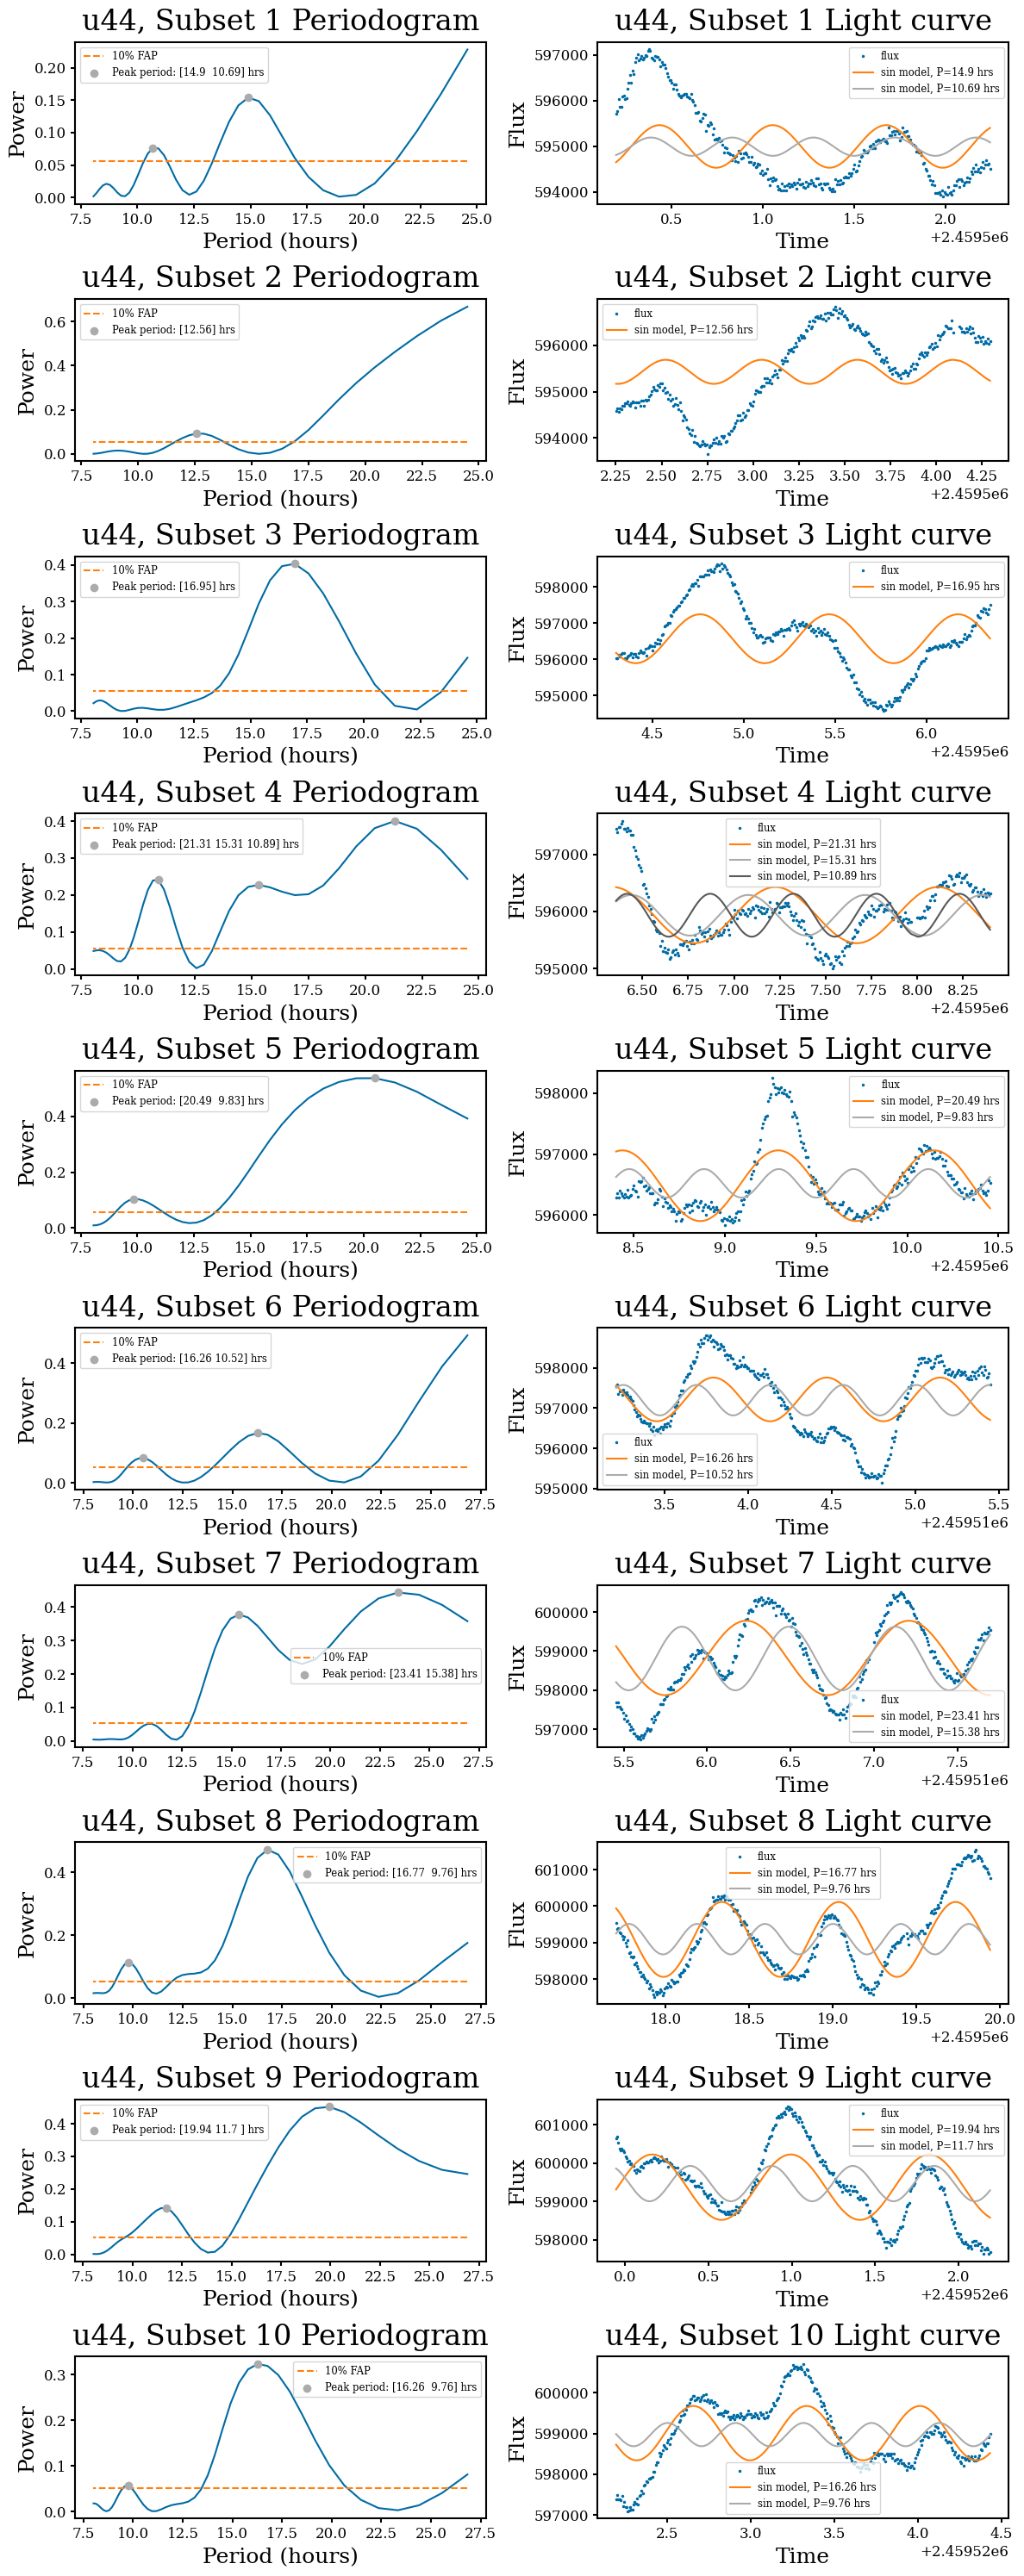

processing n42


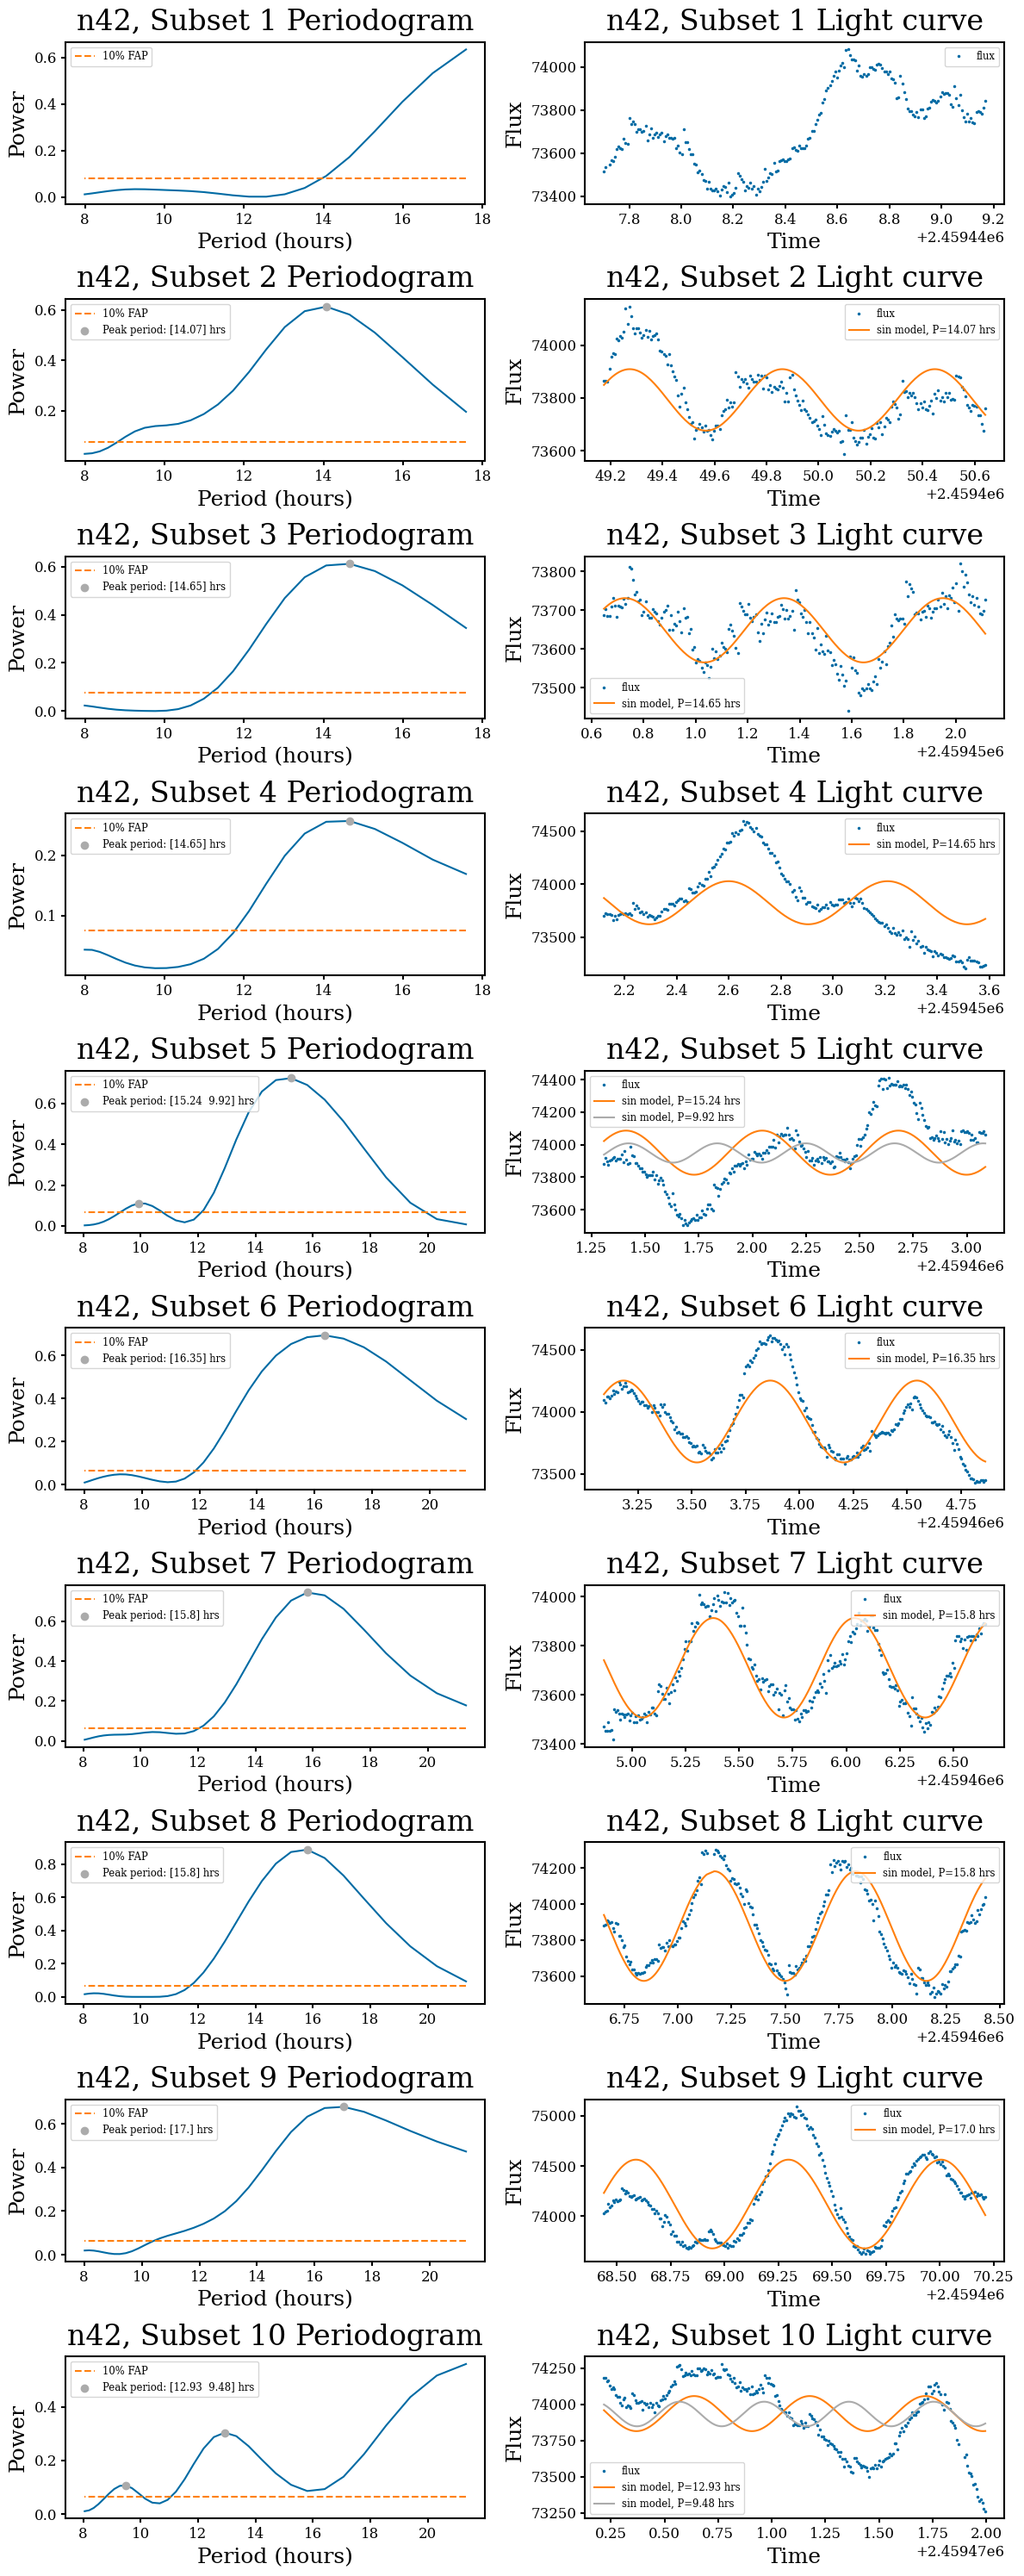

processing n70


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

def check_subsectors_grid_iterate(subtimes, subfluxes, s_index,
                                  sample_cadences, max_freq_arr,
                                  planet_sectors, fap_level,
                                  n_rows=10):
    """
    Plots up to n_rows subsectors in an n_rows x 2 grid for sector s_index.
    Left column: periodogram (period in hours). Right column: light curve + sinusoid models.
    Iterates sub_index from 0..(n_rows-1) and places each result on its own row.

    Assumes helper funcs exist:
      nyquist_from_cadence, make_periodogram, linear_detrend, get_peak_frequencies
    """

    # recompute nyquist-limited max frequency array (keeps behavior similar to original)
    max_freq_arr = nyquist_from_cadence(sample_cadences)

    rows = max(1, min(10, n_rows))    # clamp to 1..10
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    if rows == 1:
        axes = axes.reshape(1, 2)

    for i in range(rows):
        sub_index = i  # iterate down each row: sub_index = 0,1,...,rows-1

        # Guard: ensure the subsector exists
        try:
            test_t = subtimes[s_index][sub_index]
            test_lc = subfluxes[s_index][sub_index]
        except IndexError:
            # hide unused axes and continue
            axes[i, 0].axis('off')
            axes[i, 1].axis('off')
            continue

        # frequency bounds
        max_period = (test_t[-1] - test_t[0]) / 2.0
        min_freq = 1.0 / max_period

        frequency, power, false_alarm_levels = make_periodogram(
            test_t,
            linear_detrend(test_t, test_lc)[2],
            minimum_frequency=min_freq,
            maximum_frequency=max_freq_arr[s_index],
            samples_per_peak=10,
            probabilities=[fap_level],
            n_bootstrap=1000
        )

        peakfreq, peakpow = get_peak_frequencies(frequency, power, false_alarm_levels[0])

        # Left: periodogram (period in hours)
        ax_p = axes[i, 0]
        ax_p.plot(24.0 / frequency, power, color='C0')
        ax_p.plot(24.0 / frequency, false_alarm_levels[0], color='C1', linestyle='--',
                  label=f"{fap_level}% FAP")
        if len(peakfreq) > 0:
            ax_p.scatter(24.0 / peakfreq, peakpow, color='C2', zorder=5,
                         label=f"Peak period: {np.round(24.0/peakfreq, 2)} hrs")
        ax_p.set_xlabel("Period (hours)")
        ax_p.set_ylabel("Power")
        ax_p.set_title(f"{planet_sectors[s_index]}, Subset {sub_index + 1} Periodogram")
        ax_p.legend(fontsize='small')

        # Right: light curve + models
        ax_lc = axes[i, 1]
        ax_lc.plot(test_t, test_lc, '.', markersize=3, label="flux")
        for peak in peakfreq:
            model = LombScargle(test_t, test_lc).model(test_t, peak)
            ax_lc.plot(test_t, model, label=f"sin model, P={np.round(24.0/peak,2)} hrs")
        ax_lc.set_xlabel("Time")
        ax_lc.set_ylabel("Flux")
        ax_lc.set_title(f"{planet_sectors[s_index]}, Subset {sub_index + 1} Light curve")
        ax_lc.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

for fap_level in [10, 1, 0.1]:
    print(f"fap levep: {fap_level}")
    for s_index in range(5):  
        print(f"processing {planet_sectors[s_index]}")
        check_subsectors_grid_iterate(subtimes, subfluxes, s_index=s_index,
                                    sample_cadences=sample_cadences,
                                    max_freq_arr=max_freq_arr,
                                    planet_sectors=planet_sectors,
                                    fap_level=fap_level, n_rows=10)


In [ ]:
from bootstrap import save_bootstrap
from orbit_correction import linear_detrend

for i, sector in enumerate(planet_sectors):
    for j, subsector in enumerate(subtimes[i]):
        _, _, detrended_flux = linear_detrend(subtimes[i][j], subfluxes[i][j])
        subsector_data_list = [{'time': subtimes[i][j], 'detrended': detrended_flux}]
        save_bootstrap(subsector_data_list, 
                       [f"{sector}_subsector_{j}"]*len(subtimes[i][j]), 
                       root + "subsectors/", n_bootstraps=1000, plot=False)
        
# save_bootstrap(sector_data_list, sector_data_strings, root, flux_type='detrended', fap_level=0.1, min_period=0.1, max_period=1,
#                    n_freqs=int(1e5), n_bootstraps=10000, plot=True)

100%|██████████| 1000/1000 [02:15<00:00,  7.38it/s]


In [ ]:
from bootstrap import save_cluster
from fullsector import get_peak_frequencies

for i, sector in enumerate(planet_sectors):
    subboot_dir = root + f"subsectors/"
    subperiodogram_list = []
    subbootstrap_list = []
    for j, file in enumerate(os.listdir(subboot_dir)):
        if file.endswith(".npz"):
            subbootstrap_list.append(np.load(subboot_dir + file, allow_pickle=True)["peak_periods"])
            peaks, _ = get_peak_frequencies(subfreqs, subpower[i][j], subfap[i][j])
            # print(1/peaks)
            subperiodogram_list.append({'peaks': peaks})
            # print(subbootstrap_list[-1])

    save_cluster(subperiodogram_list, 
            subbootstrap_list, 
            [f"{sector}_subsector_{j}" for j in range(len(subtimes[i]))], 
            root + f"subsectors/{sector}/clusters/",
            eps=0.0001, 
            ncols=3, 
            plot=True,
            n_bootstraps=1000)

KeyError: 'peak_periods is not a file in the archive'